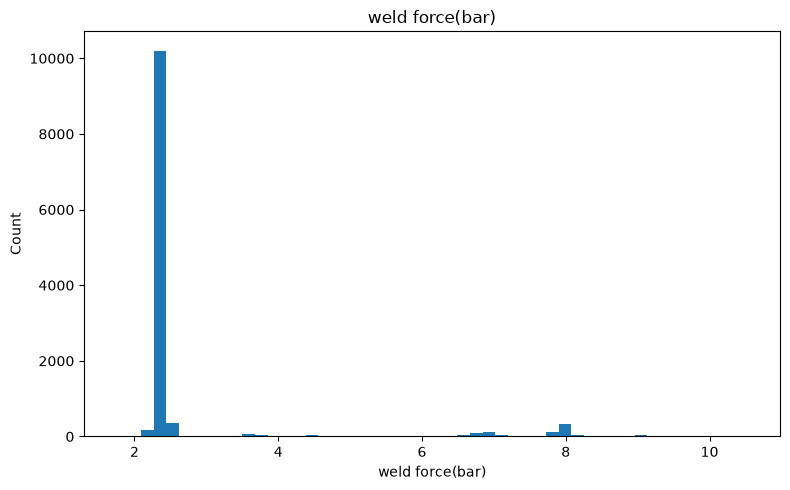

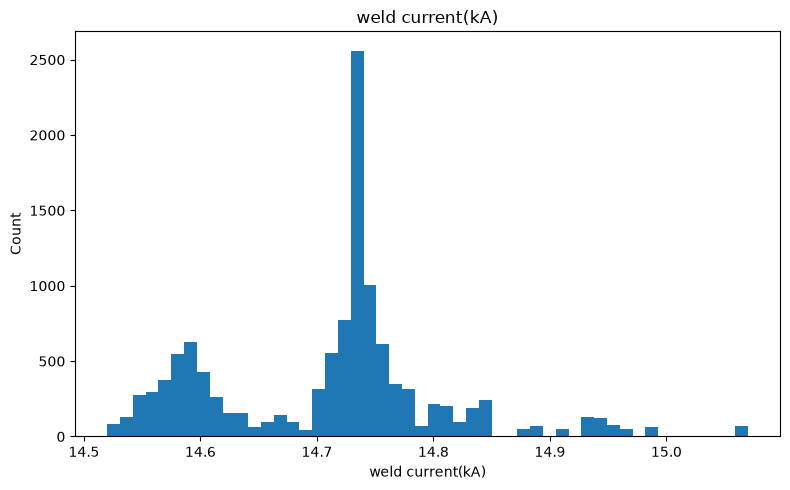

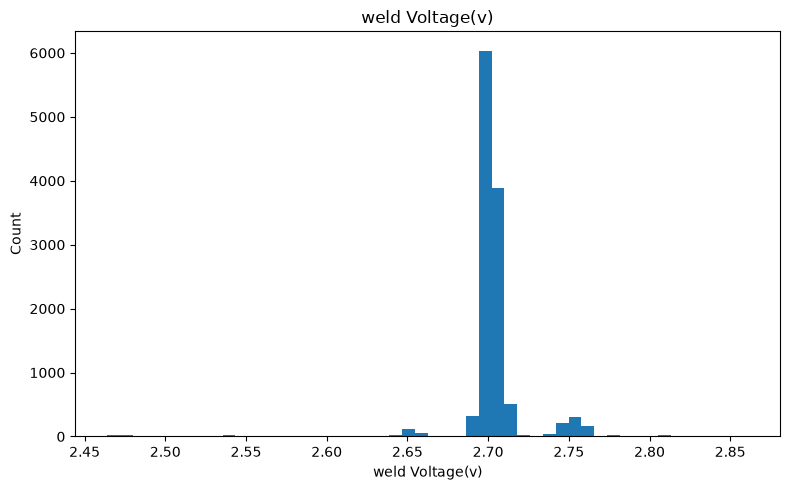

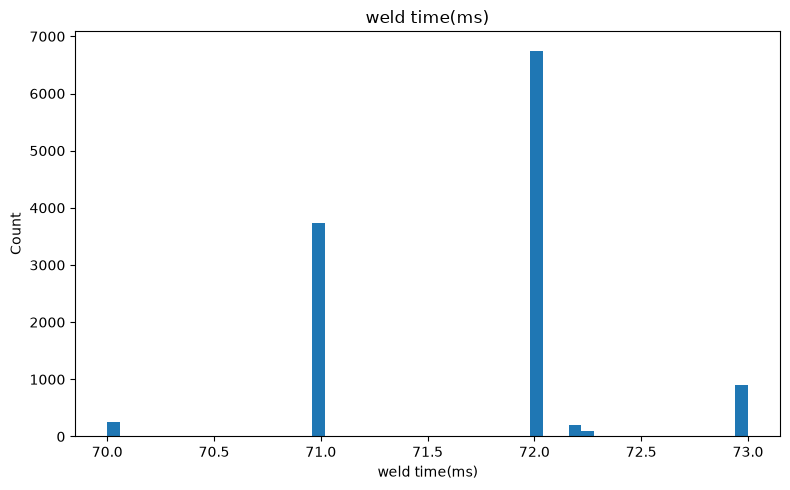

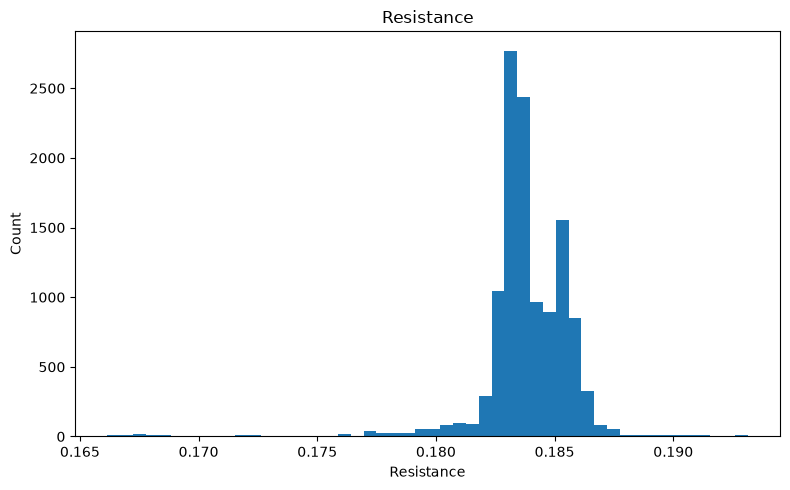

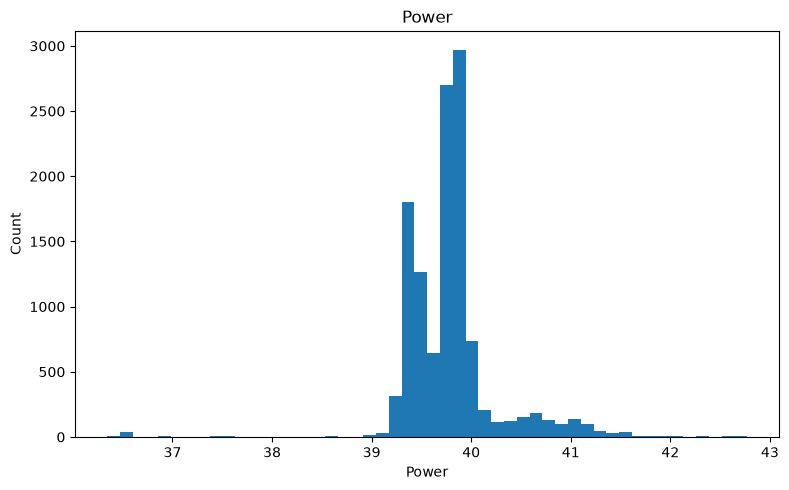

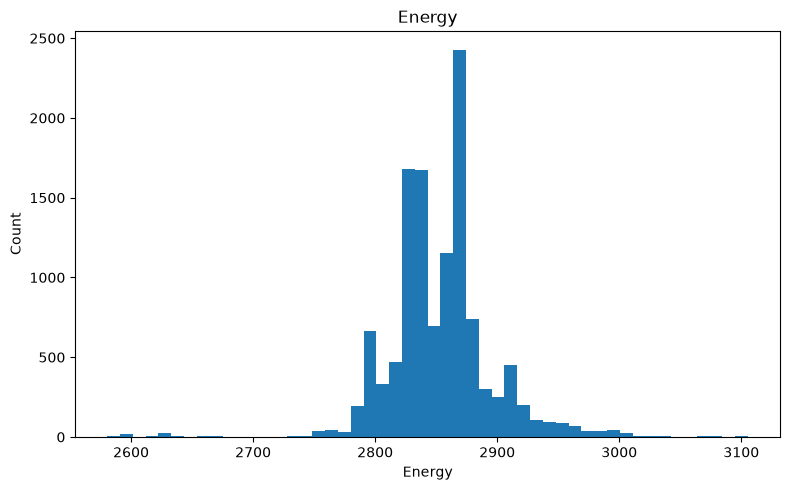

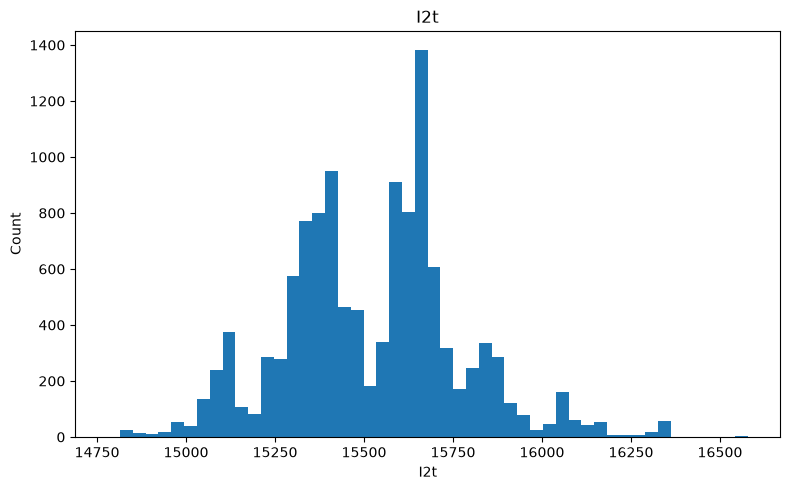

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 원본 엑셀 불러오기
df = pd.read_excel("experiments/YSJ/YSJ-001/Welding Data Set_01.xlsx")

# 파생변수 4개 생성
df["Resistance"] = df["weld Voltage(v)"] / df["weld current(kA)"]
df["Power"] = df["weld Voltage(v)"] * df["weld current(kA)"]
df["Energy"] = df["weld Voltage(v)"] * df["weld current(kA)"] * df["weld time(ms)"]
df["I2t"] = (df["weld current(kA)"] ** 2) * df["weld time(ms)"]

# 총 8개 변수
features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)",
    "Resistance",
    "Power",
    "Energy",
    "I2t"
]

# 히스토그램 8개
for column in features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=50)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 데이터 불러오기
df = pd.read_excel(
    "experiments/YSJ/YSJ-001/Welding Data Set_01.xlsx"
)

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# Energy
df["Energy"] = (
    df["weld Voltage(v)"]
    * df["weld current(kA)"]
    * df["weld time(ms)"]
)

# Resistance
df["Resistance"] = (
    df["weld Voltage(v)"]
    / df["weld current(kA)"]
)

# 날짜별 Current MAD
def mad(x):
    median = x.median()
    return (x - median).abs().median()

daily_mad = (
    df.groupby("date")["weld current(kA)"]
    .apply(mad)
)

df["Current_MAD"] = df["date"].map(daily_mad)

df[["date", "Current_MAD", "Energy", "Resistance"]].head()

,date,Current_MAD,Energy,Resistance
0,2020-03-24,0.04,2833.45704,0.185381
1,2020-03-24,0.04,2833.45704,0.185381
2,2020-03-24,0.04,2790.41502,0.185901
3,2020-03-24,0.04,2829.71664,0.185901
4,2020-03-24,0.04,2834.65728,0.185714


In [16]:
features = [
    "Current_MAD",
    "Energy",
    "Resistance"
]

model_df = df[features].dropna().copy()

scaler = StandardScaler()

X = scaler.fit_transform(model_df)

print("사용 행 개수:", len(model_df))
print("사용 변수:", features)

사용 행 개수: 11939
사용 변수: ['Current_MAD', 'Energy', 'Resistance']


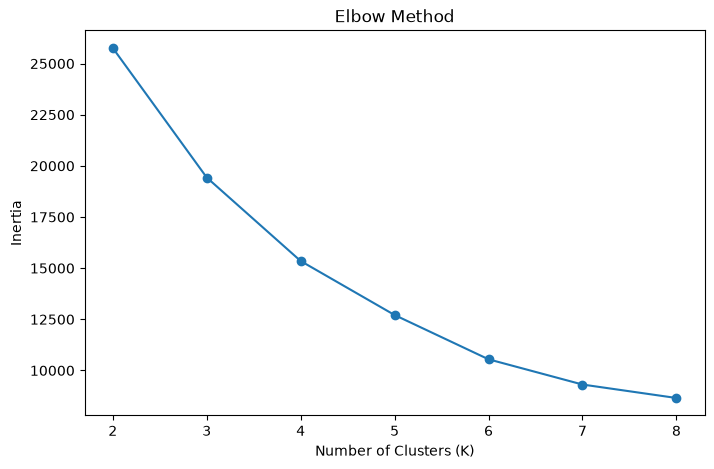

In [17]:
inertias = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X)

# 원본 데이터에도 cluster 붙이기
df.loc[model_df.index, "Cluster"] = model_df["Cluster"]

print(model_df["Cluster"].value_counts())

Cluster
1    6193
0    5670
2      76
Name: count, dtype: int64


In [20]:
cluster_summary = (
    model_df
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_summary)

         Current_MAD       Energy  Resistance
Cluster                                      
0           0.054068  2850.392365    0.184192
1           0.028035  2858.710342    0.183677
2           0.043750  2641.739528    0.168909


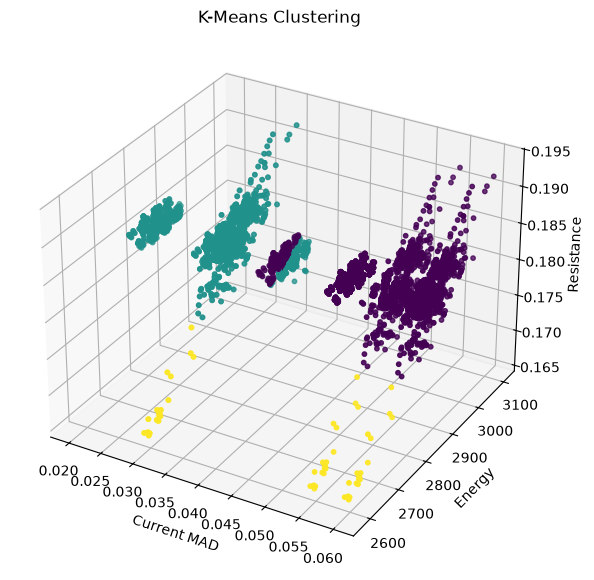

In [21]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    model_df["Current_MAD"],
    model_df["Energy"],
    model_df["Resistance"],
    c=model_df["Cluster"],
    s=10
)

ax.set_xlabel("Current MAD")
ax.set_ylabel("Energy")
ax.set_zlabel("Resistance")

plt.title("K-Means Clustering")

plt.show()

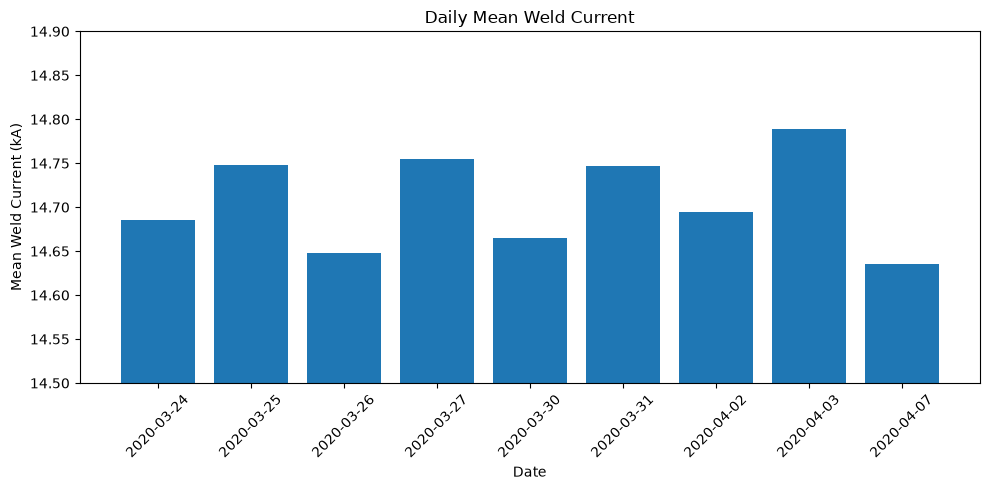

date
2020-03-24    14.685817
2020-03-25    14.748203
2020-03-26    14.648110
2020-03-27    14.754266
2020-03-30    14.664592
2020-03-31    14.746411
2020-04-02    14.694350
2020-04-03    14.788625
2020-04-07    14.635770
Name: weld current(kA), dtype: float64


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 만들기
df["date"] = pd.to_datetime(df["working time"]).dt.date

# 날짜별 평균 전류
daily_current = (
    df.groupby("date")["weld current(kA)"]
    .mean()
)

# 그래프
plt.figure(figsize=(10, 5))

plt.bar(
    [str(x) for x in daily_current.index],
    daily_current.values
)

plt.xlabel("Date")
plt.ylabel("Mean Weld Current (kA)")
plt.title("Daily Mean Weld Current")

plt.xticks(rotation=45)
plt.ylim(14.5, 14.9)

plt.tight_layout()
plt.show()

# 실제 값 출력
print(daily_current)

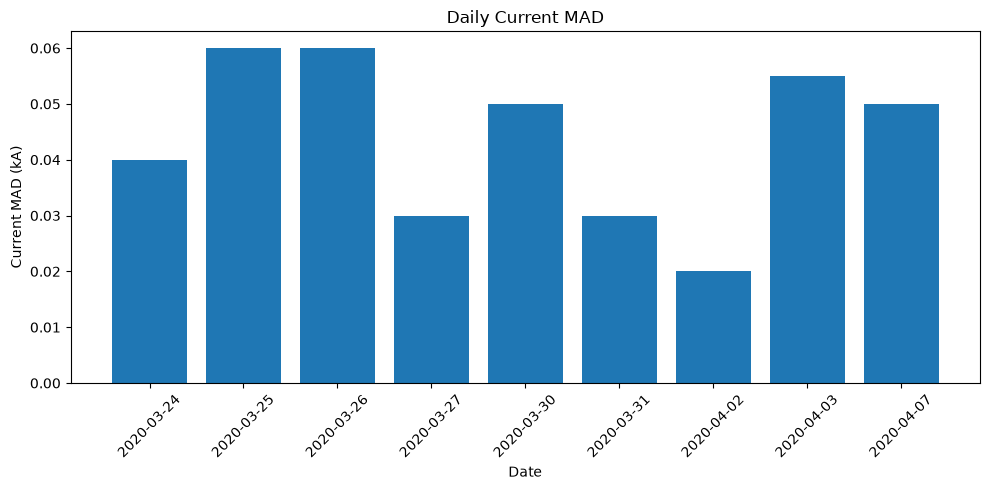

date
2020-03-24    0.040
2020-03-25    0.060
2020-03-26    0.060
2020-03-27    0.030
2020-03-30    0.050
2020-03-31    0.030
2020-04-02    0.020
2020-04-03    0.055
2020-04-07    0.050
Name: weld current(kA), dtype: float64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# MAD 함수
def mad(x):
    median = x.median()
    return (x - median).abs().median()

# 날짜별 Current MAD
daily_mad = df.groupby("date")["weld current(kA)"].apply(mad)

# 그래프
plt.figure(figsize=(10, 5))

plt.bar(
    [str(x) for x in daily_mad.index],
    daily_mad.values
)

plt.xlabel("Date")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Current MAD")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 실제 수치 출력
print(daily_mad)

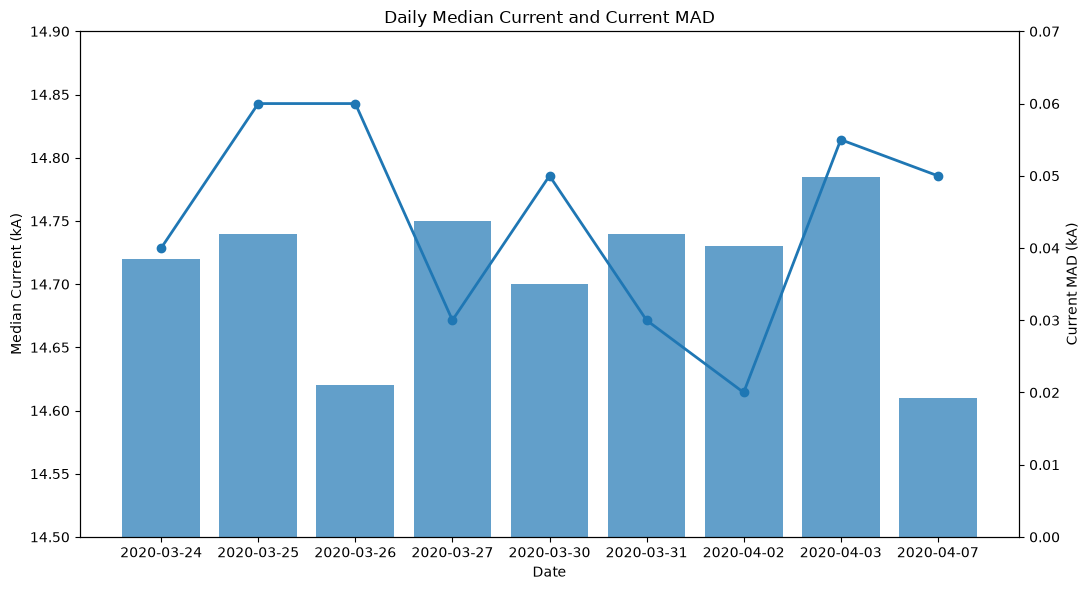

            Median_Current  Current_MAD
date                                   
2020-03-24          14.720        0.040
2020-03-25          14.740        0.060
2020-03-26          14.620        0.060
2020-03-27          14.750        0.030
2020-03-30          14.700        0.050
2020-03-31          14.740        0.030
2020-04-02          14.730        0.020
2020-04-03          14.785        0.055
2020-04-07          14.610        0.050


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 생성
df["date"] = pd.to_datetime(df["working time"]).dt.date

# MAD 함수
def mad(x):
    median = x.median()
    return (x - median).abs().median()

# 날짜별 중앙값
daily_median = df.groupby("date")["weld current(kA)"].median()

# 날짜별 MAD
daily_mad = df.groupby("date")["weld current(kA)"].apply(mad)

# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

# 중앙값 - 막대
ax1.bar(
    [str(x) for x in daily_median.index],
    daily_median.values,
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Current (kA)")
ax1.set_ylim(14.5, 14.9)

# MAD - 선 그래프
ax2 = ax1.twinx()

ax2.plot(
    [str(x) for x in daily_mad.index],
    daily_mad.values,
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Current MAD (kA)")
ax2.set_ylim(0, 0.07)

plt.title("Daily Median Current and Current MAD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 수치도 출력
result = pd.DataFrame({
    "Median_Current": daily_median,
    "Current_MAD": daily_mad
})

print(result)

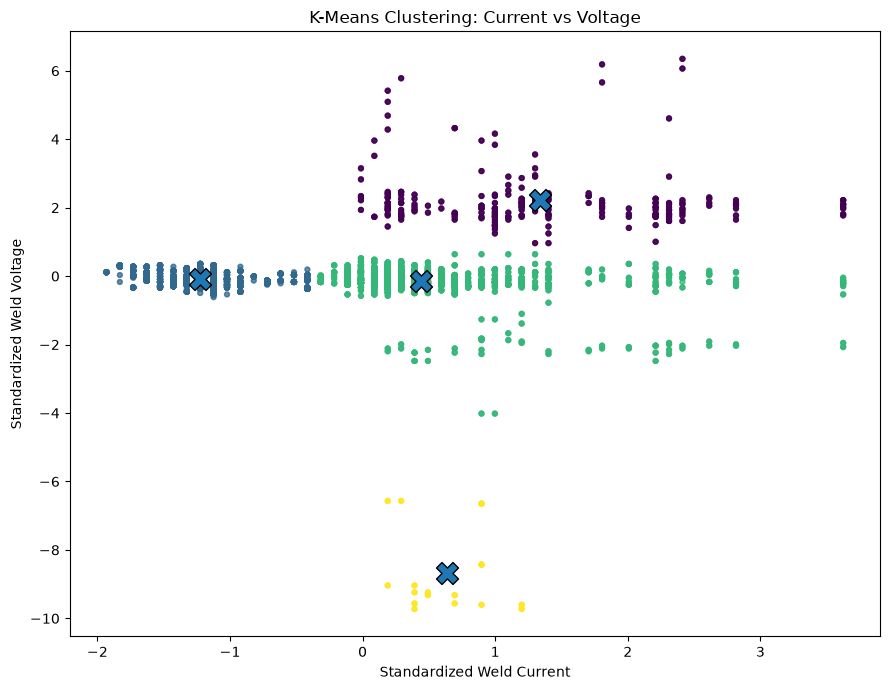

In [30]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 사용할 변수
features = [
    "weld current(kA)",
    "weld Voltage(v)"
]

model_df = df[features].dropna().copy()

# 2. 표준화
scaler = StandardScaler()
X = scaler.fit_transform(model_df[features])

# 3. K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X)

# 4. 표준화 공간에서 중심점
centers = kmeans.cluster_centers_

# 5. 그래프
plt.figure(figsize=(9, 7))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=model_df["Cluster"],
    s=12,
    alpha=0.5
)

# 군집 중심
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    edgecolors="black"
)

plt.xlabel("Standardized Weld Current")
plt.ylabel("Standardized Weld Voltage")
plt.title("K-Means Clustering: Current vs Voltage")

plt.tight_layout()
plt.show()

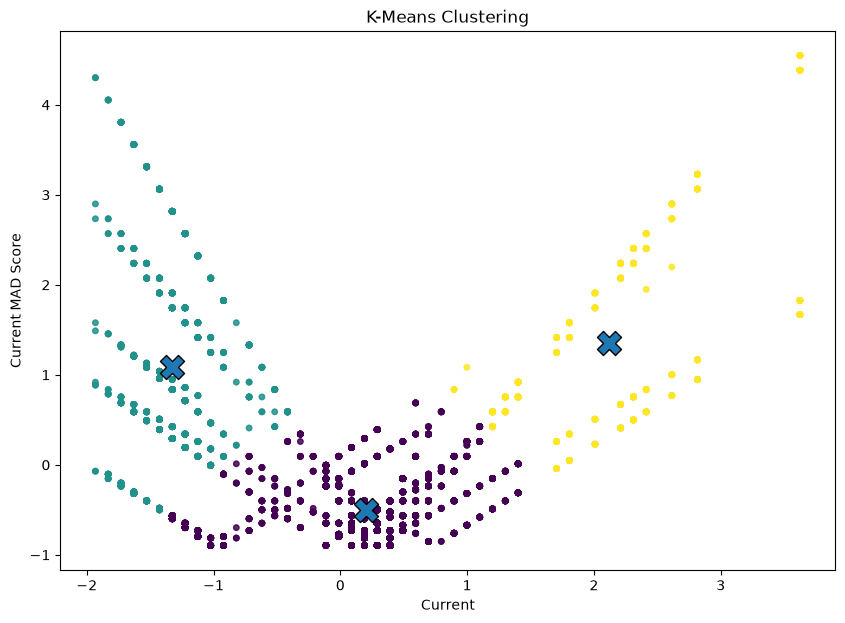

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 모델링에 사용할 변수
X = df[[
    "weld current(kA)",
    "Current_MAD_Score"
]].dropna()

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means 모델
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# 군집 예측
clusters = kmeans.fit_predict(X_scaled)

# 그래프
plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=15,
    alpha=0.6
)

# 군집 중심
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    edgecolors="black"
)

plt.xlabel("Current")
plt.ylabel("Current MAD Score")
plt.title("K-Means Clustering")

plt.show()

K-Means에 사용되는 전체 행: 11939


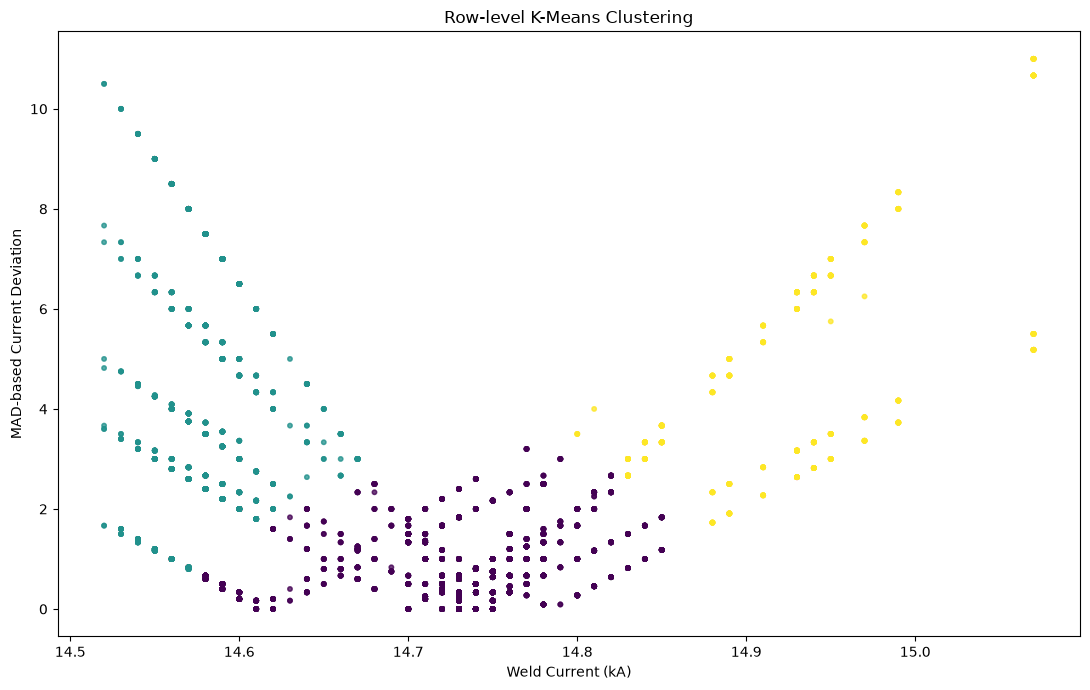


Cluster별 행 개수
Cluster
0    8335
1    2704
2     900
Name: count, dtype: int64

Cluster별 평균
         weld current(kA)  MAD_Score
Cluster                             
0               14.731109   0.804790
1               14.580126   4.000168
2               14.920733   4.540606


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =====================================================
# 1. 날짜 생성
# =====================================================

df["date"] = pd.to_datetime(df["working time"]).dt.date


# =====================================================
# 2. 날짜별 전류 중앙값
# =====================================================

df["Daily_Median"] = (
    df.groupby("date")["weld current(kA)"]
      .transform("median")
)


# =====================================================
# 3. 각 행의 전류 편차
# |현재 전류 - 해당 날짜 중앙값|
# =====================================================

df["Current_Deviation"] = abs(
    df["weld current(kA)"] - df["Daily_Median"]
)


# =====================================================
# 4. 날짜별 MAD
# =====================================================

df["Daily_MAD"] = (
    df.groupby("date")["Current_Deviation"]
      .transform("median")
)


# =====================================================
# 5. 각 행의 MAD 기준 이탈도
# 이 값이 2 → 해당 날짜 MAD의 2배만큼 이탈
# =====================================================

df["MAD_Score"] = (
    df["Current_Deviation"] / df["Daily_MAD"]
)

# 무한값 제거
df["MAD_Score"] = df["MAD_Score"].replace(
    [np.inf, -np.inf],
    np.nan
)


# =====================================================
# 6. K-Means 입력 데이터
# =====================================================

model_df = df[
    [
        "weld current(kA)",
        "MAD_Score"
    ]
].dropna().copy()

print("K-Means에 사용되는 전체 행:", len(model_df))


# =====================================================
# 7. 표준화
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    model_df[
        [
            "weld current(kA)",
            "MAD_Score"
        ]
    ]
)


# =====================================================
# 8. K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_df["Cluster"] = kmeans.fit_predict(X_scaled)


# =====================================================
# 9. 11,000여 개 행 전체 시각화
# =====================================================

plt.figure(figsize=(11, 7))

plt.scatter(
    model_df["weld current(kA)"],
    model_df["MAD_Score"],
    c=model_df["Cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("MAD-based Current Deviation")
plt.title("Row-level K-Means Clustering")

plt.tight_layout()
plt.show()


# =====================================================
# 10. 군집별 행 개수
# =====================================================

print("\nCluster별 행 개수")
print(model_df["Cluster"].value_counts().sort_index())


# =====================================================
# 11. 군집별 특징
# =====================================================

print("\nCluster별 평균")
print(
    model_df.groupby("Cluster")[
        ["weld current(kA)", "MAD_Score"]
    ].mean()
)

전체 모델링 행 개수: 11939
K=2, Silhouette=0.596
K=3, Silhouette=0.444
K=4, Silhouette=0.467
K=5, Silhouette=0.512
K=6, Silhouette=0.515


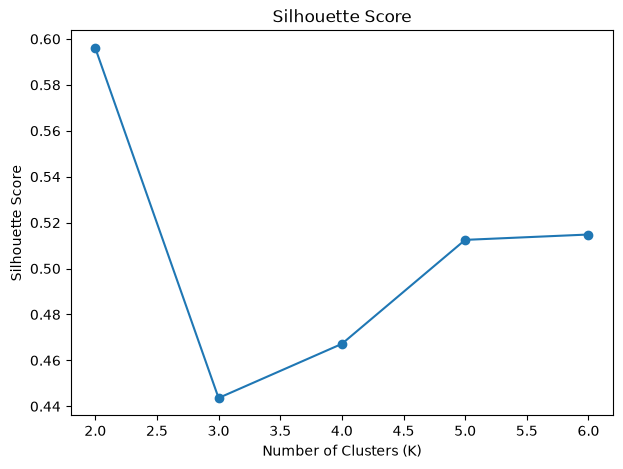

선택된 K: 2


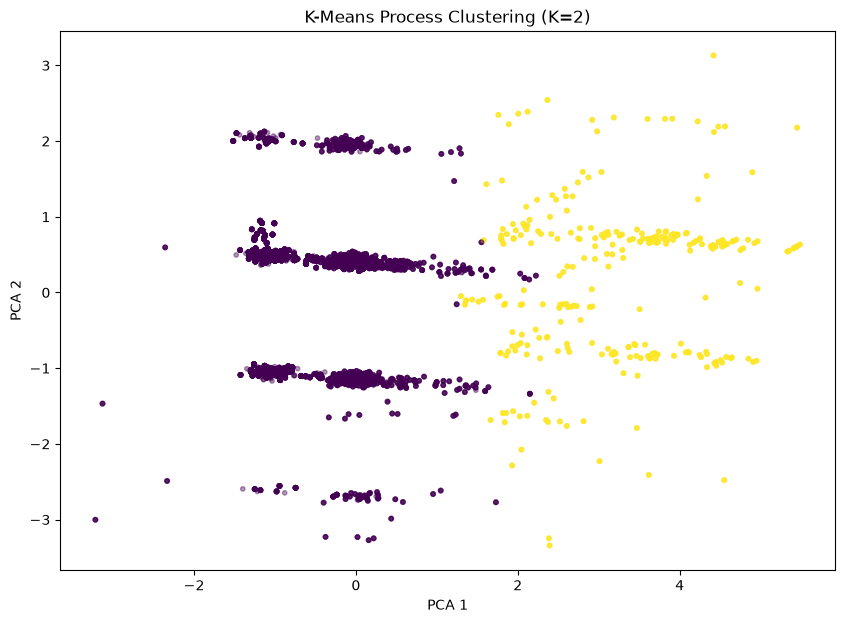


=== Cluster별 행 개수 ===
Cluster
0    10827
1     1112
Name: count, dtype: int64

=== Cluster별 공정변수 평균 ===
         weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)
Cluster                                                                   
0                  2.380            14.697            2.701         71.725
1                  6.756            14.849            2.738         71.712

=== Cluster별 공정변수 중앙값 ===
         weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)
Cluster                                                                   
0                  2.330             14.73            2.702           72.0
1                  7.375             14.83            2.752           72.0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# =====================================================
# 1. 4개 원본 공정변수
# =====================================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

model_df = df[features].dropna().copy()

print("전체 모델링 행 개수:", len(model_df))


# =====================================================
# 2. 표준화
# =====================================================

scaler = StandardScaler()
X = scaler.fit_transform(model_df)


# =====================================================
# 3. K=2~6 비교
# =====================================================

scores = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels,
        sample_size=min(5000, len(X)),
        random_state=42
    )

    scores.append(score)

    print(f"K={k}, Silhouette={score:.3f}")


# =====================================================
# 4. Silhouette 그래프
# =====================================================

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()


# =====================================================
# 5. 가장 높은 Silhouette의 K 선택
# =====================================================

best_k = range(2, 7)[scores.index(max(scores))]

print("선택된 K:", best_k)


# =====================================================
# 6. 최종 K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

model_df["Cluster"] = kmeans.fit_predict(X)


# =====================================================
# 7. PCA - 4차원을 2차원으로 시각화
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=model_df["Cluster"],
    s=10,
    alpha=0.4
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    f"K-Means Process Clustering (K={best_k})"
)

plt.show()


# =====================================================
# 8. 군집별 실제 공정조건 평균
# =====================================================

print("\n=== Cluster별 행 개수 ===")

print(
    model_df["Cluster"]
    .value_counts()
    .sort_index()
)


print("\n=== Cluster별 공정변수 평균 ===")

print(
    model_df.groupby("Cluster")[features]
    .mean()
    .round(3)
)


print("\n=== Cluster별 공정변수 중앙값 ===")

print(
    model_df.groupby("Cluster")[features]
    .median()
    .round(3)
)

전체 행: 11939
Force 2.0~2.6 행: 10739
K=2 | Silhouette=0.557
K=3 | Silhouette=0.575
K=4 | Silhouette=0.562
K=5 | Silhouette=0.454
K=6 | Silhouette=0.430


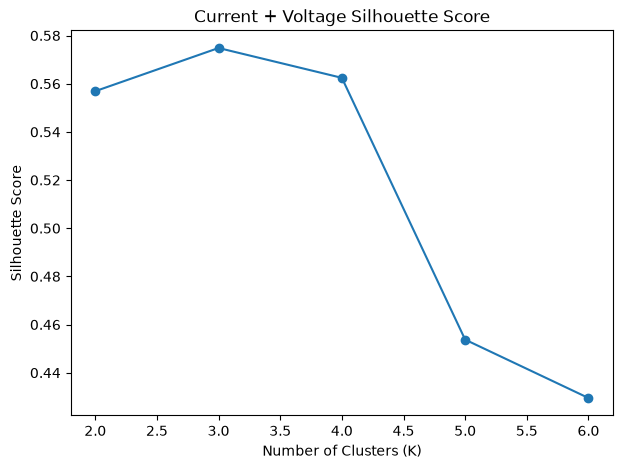

Best K = 3


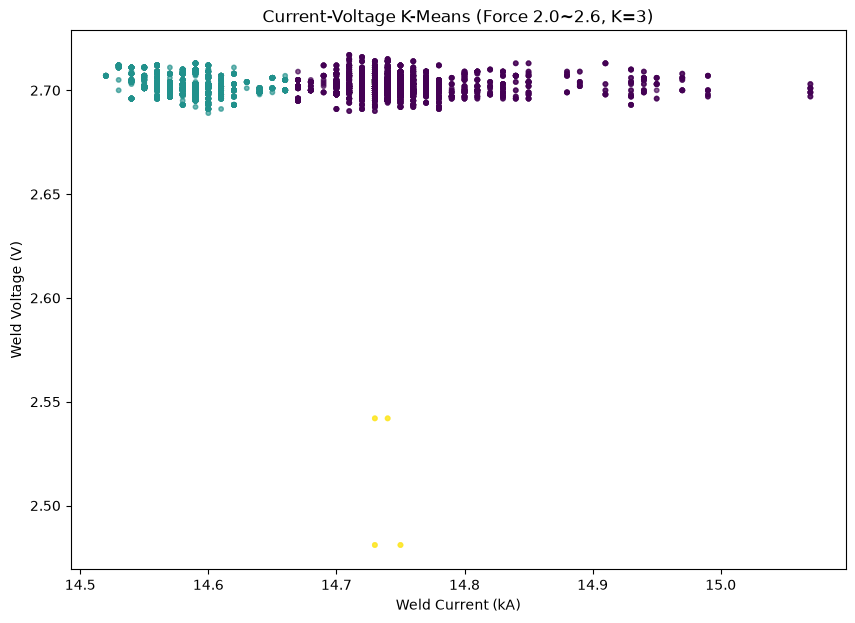


=== Cluster Count ===
Cluster
0    7232
1    3491
2      16
Name: count, dtype: int64

=== Cluster Mean ===
         weld current(kA)  weld Voltage(v)
Cluster                                   
0                 14.7494           2.7021
1                 14.5864           2.7023
2                 14.7375           2.5115

=== Cluster Median ===
         weld current(kA)  weld Voltage(v)
Cluster                                   
0                  14.740           2.7020
1                  14.590           2.7020
2                  14.735           2.5115


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# =====================================================
# 1. Force 주 공정군만 선택
#    이전 EDA 기준 2.0 ~ 2.6 bar
# =====================================================

main_df = df[
    (df["weld force(bar)"] >= 2.0) &
    (df["weld force(bar)"] <= 2.6)
].copy()

print("전체 행:", len(df))
print("Force 2.0~2.6 행:", len(main_df))


# =====================================================
# 2. Current + Voltage
# =====================================================

features = [
    "weld current(kA)",
    "weld Voltage(v)"
]

model_df = main_df[features].dropna().copy()


# =====================================================
# 3. 표준화
# =====================================================

scaler = StandardScaler()
X = scaler.fit_transform(model_df[features])


# =====================================================
# 4. K = 2~6 비교
# =====================================================

scores = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels,
        sample_size=min(5000, len(X)),
        random_state=42
    )

    scores.append(score)

    print(f"K={k} | Silhouette={score:.3f}")


# =====================================================
# 5. Silhouette 그래프
# =====================================================

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Current + Voltage Silhouette Score")

plt.show()


# =====================================================
# 6. 가장 높은 K 선택
# =====================================================

best_k = list(range(2, 7))[scores.index(max(scores))]

print("Best K =", best_k)


# =====================================================
# 7. 최종 K-Means
# =====================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

model_df["Cluster"] = kmeans.fit_predict(X)


# =====================================================
# 8. 11,000여 행 중 해당 Force군의 모든 행 시각화
# =====================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    model_df["weld current(kA)"],
    model_df["weld Voltage(v)"],
    c=model_df["Cluster"],
    s=10,
    alpha=0.4
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("Weld Voltage (V)")
plt.title(
    f"Current-Voltage K-Means (Force 2.0~2.6, K={best_k})"
)

plt.show()


# =====================================================
# 9. 군집별 특징
# =====================================================

print("\n=== Cluster Count ===")
print(
    model_df["Cluster"]
    .value_counts()
    .sort_index()
)

print("\n=== Cluster Mean ===")
print(
    model_df
    .groupby("Cluster")[features]
    .mean()
    .round(4)
)

print("\n=== Cluster Median ===")
print(
    model_df
    .groupby("Cluster")[features]
    .median()
    .round(4)
)

=== 날짜별 Cluster 개수 ===
Cluster        0    1  2
date                    
2020-03-24   786  414  0
2020-03-25   767  281  4
2020-03-26   440  560  0
2020-03-27  1132  212  4
2020-03-30   809  661  0
2020-03-31  1214  282  4
2020-04-02  1440  560  0
2020-04-03   401   95  4
2020-04-07   243  426  0

=== 날짜별 Cluster 비율(%) ===
Cluster         0      1     2
date                          
2020-03-24  65.50  34.50  0.00
2020-03-25  72.91  26.71  0.38
2020-03-26  44.00  56.00  0.00
2020-03-27  83.98  15.73  0.30
2020-03-30  55.03  44.97  0.00
2020-03-31  80.93  18.80  0.27
2020-04-02  72.00  28.00  0.00
2020-04-03  80.20  19.00  0.80
2020-04-07  36.32  63.68  0.00


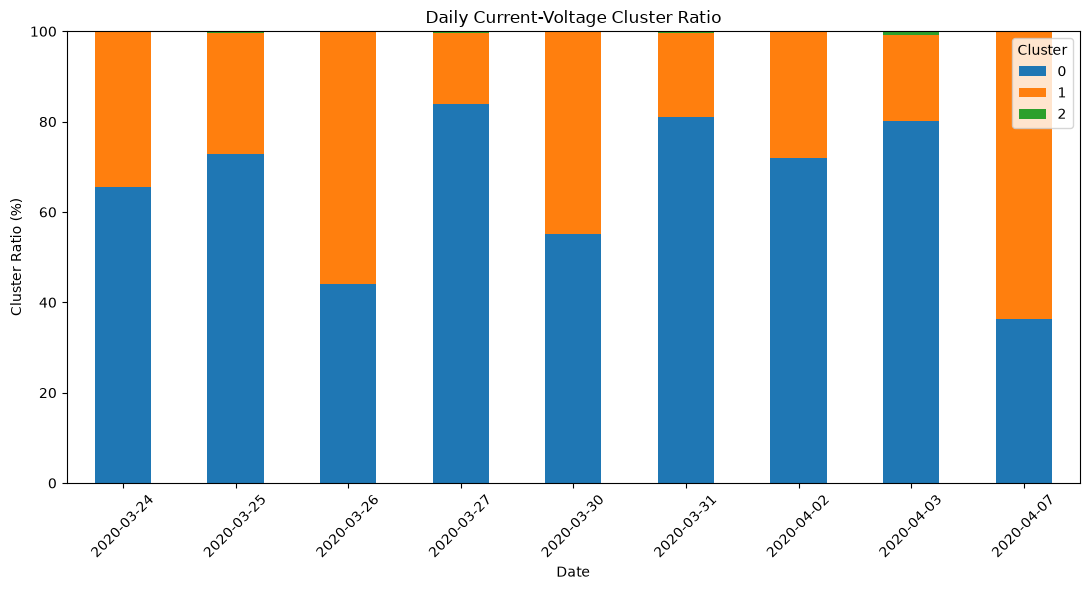

In [36]:
# 원본 행 번호 보존
model_df["date"] = main_df.loc[model_df.index, "date"]

# 날짜별 Cluster 개수
cluster_count = pd.crosstab(
    model_df["date"],
    model_df["Cluster"]
)

# 날짜별 Cluster 비율(%)
cluster_ratio = pd.crosstab(
    model_df["date"],
    model_df["Cluster"],
    normalize="index"
) * 100

print("=== 날짜별 Cluster 개수 ===")
print(cluster_count)

print("\n=== 날짜별 Cluster 비율(%) ===")
print(cluster_ratio.round(2))


# 그래프
cluster_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.ylabel("Cluster Ratio (%)")
plt.xlabel("Date")
plt.title("Daily Current-Voltage Cluster Ratio")
plt.xticks(rotation=45)
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

            Low_Current_Cluster_Ratio  Current_MAD
date                                              
2020-03-24                    34.5000        0.040
2020-03-25                    26.7110        0.060
2020-03-26                    56.0000        0.060
2020-03-27                    15.7270        0.030
2020-03-30                    44.9660        0.050
2020-03-31                    18.8000        0.030
2020-04-02                    28.0000        0.020
2020-04-03                    19.0000        0.055
2020-04-07                    63.6771        0.050


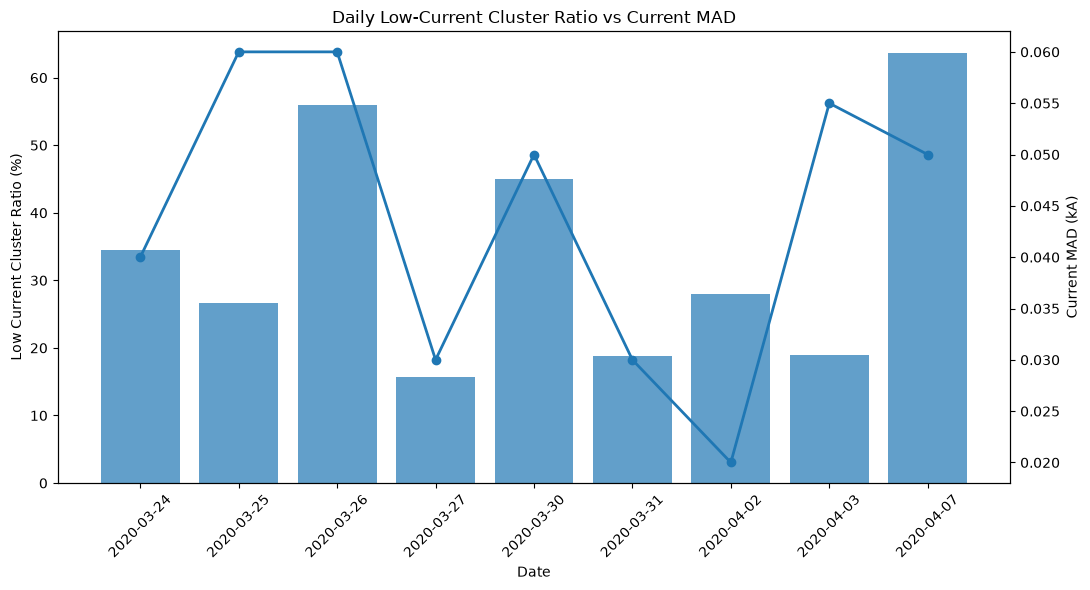

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 날짜별 Current MAD 계산
# ==========================================

def mad(x):
    median = x.median()
    return (x - median).abs().median()

daily_mad = (
    df.groupby("date")["weld current(kA)"]
      .apply(mad)
)


# ==========================================
# 2. K-means 결과에 날짜 연결
# ==========================================

model_df["date"] = main_df.loc[model_df.index, "date"]


# ==========================================
# 3. 날짜별 저전류 Cluster 1 비율
# ==========================================

low_current_ratio = (
    model_df.groupby("date")["Cluster"]
    .apply(lambda x: (x == 1).mean() * 100)
)


# ==========================================
# 4. 하나의 데이터프레임으로 합치기
# ==========================================

daily_result = pd.DataFrame({
    "Low_Current_Cluster_Ratio": low_current_ratio,
    "Current_MAD": daily_mad
}).dropna()

print(daily_result.round(4))


# ==========================================
# 5. 그래프
# ==========================================

fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in daily_result.index]

# 저전류 Cluster 비율
ax1.bar(
    dates,
    daily_result["Low_Current_Cluster_Ratio"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Low Current Cluster Ratio (%)")


# MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    daily_result["Current_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Current MAD (kA)")


plt.title("Daily Low-Current Cluster Ratio vs Current MAD")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

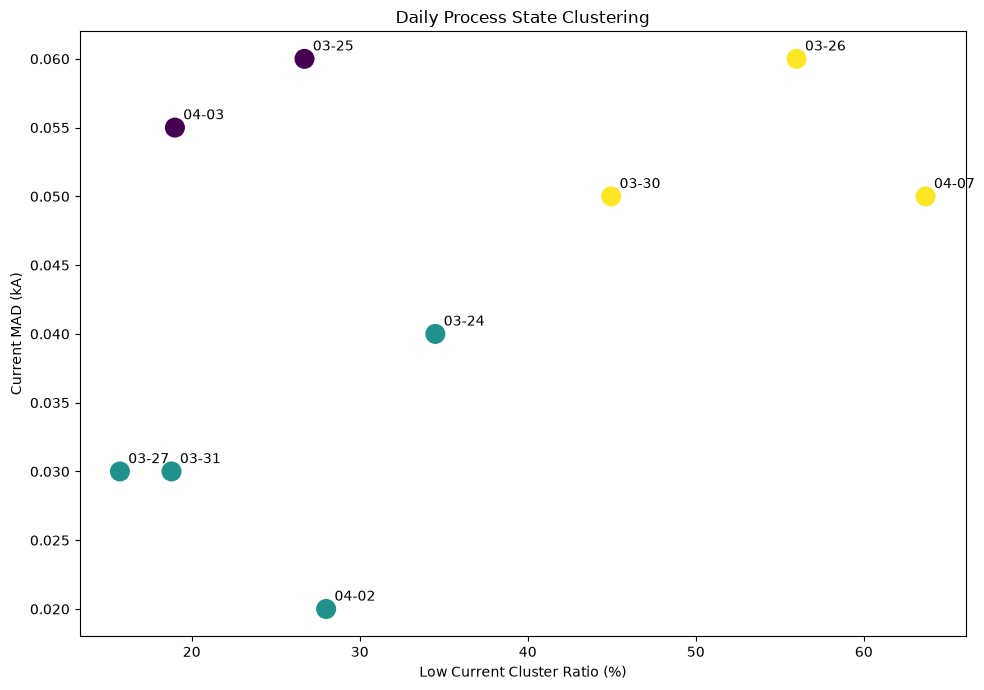

            Low_Current_Cluster_Ratio  Current_MAD  Process_Cluster
date                                                               
2020-03-24                    34.5000        0.040                1
2020-03-25                    26.7110        0.060                0
2020-03-26                    56.0000        0.060                2
2020-03-27                    15.7270        0.030                1
2020-03-30                    44.9660        0.050                2
2020-03-31                    18.8000        0.030                1
2020-04-02                    28.0000        0.020                1
2020-04-03                    19.0000        0.055                0
2020-04-07                    63.6771        0.050                2


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 사용할 변수
X = daily_result[
    ["Low_Current_Cluster_Ratio", "Current_MAD"]
].copy()

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

daily_result["Process_Cluster"] = kmeans.fit_predict(X_scaled)

# 4. 생산일별 분포 시각화
plt.figure(figsize=(10, 7))

plt.scatter(
    daily_result["Low_Current_Cluster_Ratio"],
    daily_result["Current_MAD"],
    c=daily_result["Process_Cluster"],
    s=180
)

# 날짜 표시
for date, row in daily_result.iterrows():
    plt.annotate(
        str(date)[5:],
        (
            row["Low_Current_Cluster_Ratio"],
            row["Current_MAD"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Low Current Cluster Ratio (%)")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Process State Clustering")

plt.tight_layout()
plt.show()

# 결과
print(
    daily_result[
        [
            "Low_Current_Cluster_Ratio",
            "Current_MAD",
            "Process_Cluster"
        ]
    ].round(4)
)

In [41]:
# 생산일별 군집 결과 확인
result = daily_result[
    [
        "Low_Current_Cluster_Ratio",
        "Current_MAD",
        "Process_Cluster"
    ]
].copy()

# 군집별 평균
cluster_summary = result.groupby("Process_Cluster")[
    ["Low_Current_Cluster_Ratio", "Current_MAD"]
].mean()

print("=== 날짜별 결과 ===")
print(result.round(4))

print("\n=== 군집별 평균 ===")
print(cluster_summary.round(4))

print("\n=== 군집별 날짜 ===")

for cluster in sorted(result["Process_Cluster"].unique()):
    dates = result[result["Process_Cluster"] == cluster].index

    print(f"\nCluster {cluster}")
    for date in dates:
        print(date)

=== 날짜별 결과 ===
            Low_Current_Cluster_Ratio  Current_MAD  Process_Cluster
date                                                               
2020-03-24                    34.5000        0.040                1
2020-03-25                    26.7110        0.060                0
2020-03-26                    56.0000        0.060                2
2020-03-27                    15.7270        0.030                1
2020-03-30                    44.9660        0.050                2
2020-03-31                    18.8000        0.030                1
2020-04-02                    28.0000        0.020                1
2020-04-03                    19.0000        0.055                0
2020-04-07                    63.6771        0.050                2

=== 군집별 평균 ===
                 Low_Current_Cluster_Ratio  Current_MAD
Process_Cluster                                        
0                                  22.8555       0.0575
1                                  24.2568       0.03

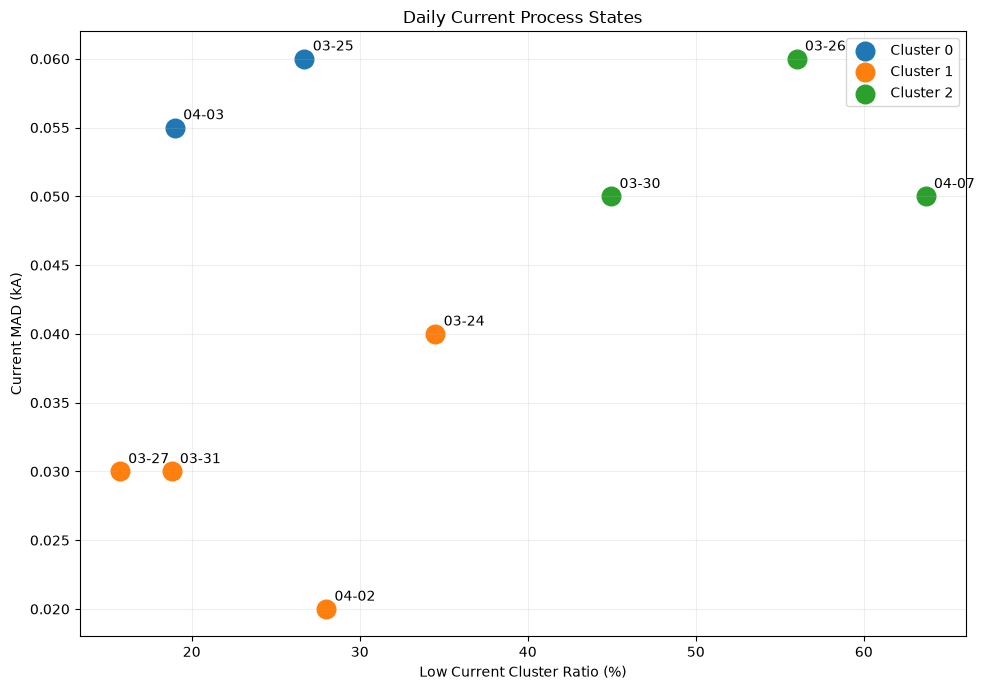

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(result["Process_Cluster"].unique()):

    temp = result[result["Process_Cluster"] == cluster]

    plt.scatter(
        temp["Low_Current_Cluster_Ratio"],
        temp["Current_MAD"],
        s=180,
        label=f"Cluster {cluster}"
    )

    for date, row in temp.iterrows():
        plt.annotate(
            str(date)[5:],
            (
                row["Low_Current_Cluster_Ratio"],
                row["Current_MAD"]
            ),
            xytext=(6, 6),
            textcoords="offset points"
        )

plt.xlabel("Low Current Cluster Ratio (%)")
plt.ylabel("Current MAD (kA)")
plt.title("Daily Current Process States")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

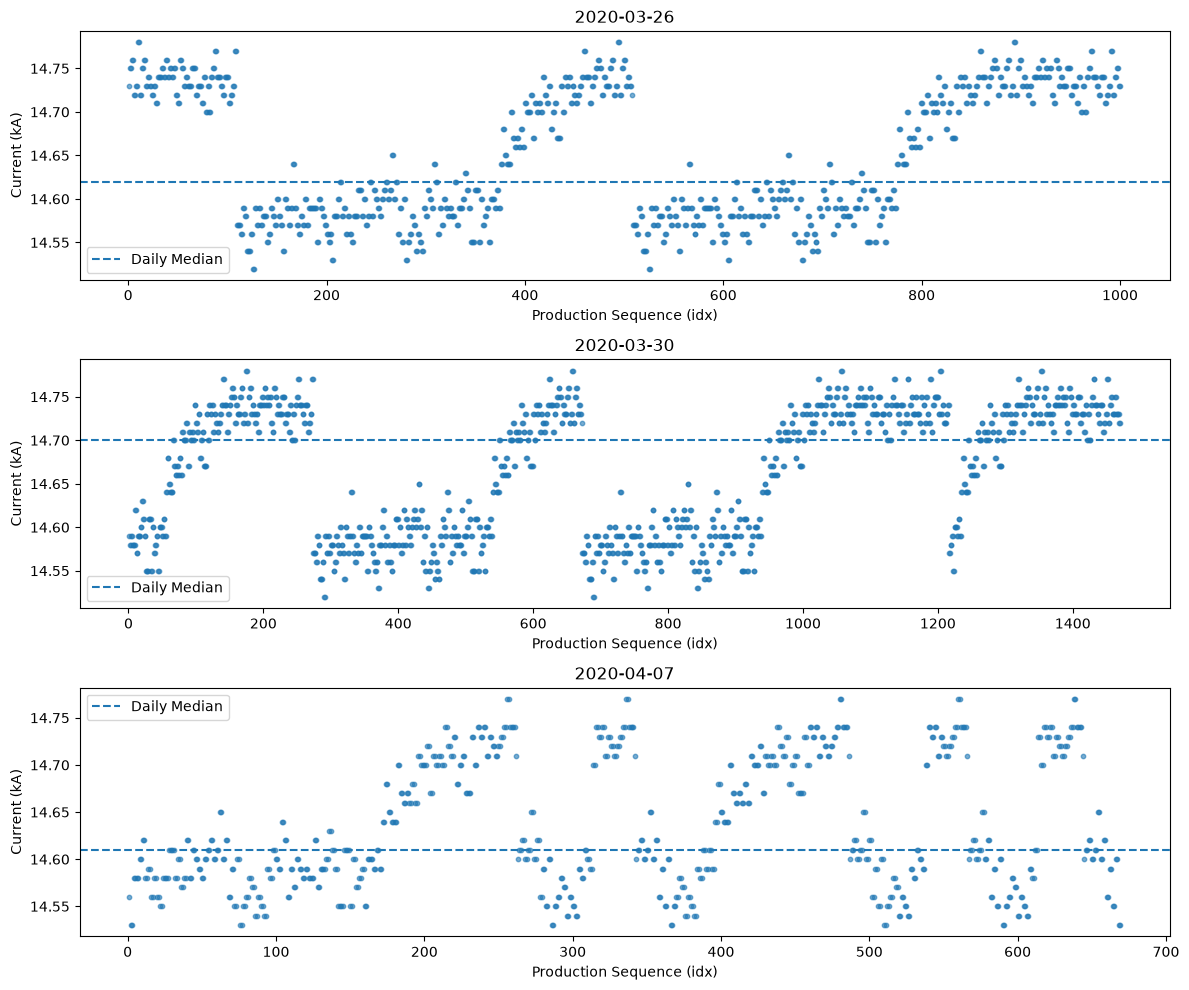

In [43]:
# 3/26, 3/30, 4/07 생산순서별 Current 확인

target_dates = [
    pd.to_datetime("2020-03-26").date(),
    pd.to_datetime("2020-03-30").date(),
    pd.to_datetime("2020-04-07").date()
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, date in zip(axes, target_dates):

    temp = df[df["date"] == date].sort_values("idx")

    ax.scatter(
        temp["idx"],
        temp["weld current(kA)"],
        s=10,
        alpha=0.6
    )

    ax.axhline(
        temp["weld current(kA)"].median(),
        linestyle="--",
        label="Daily Median"
    )

    ax.set_title(str(date))
    ax.set_xlabel("Production Sequence (idx)")
    ax.set_ylabel("Current (kA)")
    ax.legend()

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. 저전류 / 고전류 기준 자동 설정
# 이전 Current-Voltage K-means의 군집 평균 이용
# =====================================================

cluster_current_mean = (
    model_df.groupby("Cluster")["weld current(kA)"].mean()
)

# Voltage 이상군(Cluster 2 같은 극소수 군집)은 제외하고
# 행 수가 많은 2개 군집 선택
large_clusters = (
    model_df["Cluster"]
    .value_counts()
    .nlargest(2)
    .index
)

means = cluster_current_mean.loc[large_clusters].sort_values()

low_center = means.iloc[0]
high_center = means.iloc[1]

threshold = (low_center + high_center) / 2

print("Low Current Center :", round(low_center, 4))
print("High Current Center:", round(high_center, 4))
print("Threshold          :", round(threshold, 4))


# =====================================================
# 2. 모든 행을 생산순서대로 LOW / HIGH 분류
# =====================================================

analysis_df = df.dropna(
    subset=["date", "idx", "weld current(kA)"]
).copy()

analysis_df = analysis_df.sort_values(["date", "idx"])

analysis_df["Current_State"] = np.where(
    analysis_df["weld current(kA)"] < threshold,
    "LOW",
    "HIGH"
)


# =====================================================
# 3. 날짜별 전환 횟수 + 저전류 비율 + 지속구간 계산
# =====================================================

results = []

for date, temp in analysis_df.groupby("date"):

    temp = temp.sort_values("idx").copy()

    # 이전 행과 상태가 달라졌는지
    temp["State_Change"] = (
        temp["Current_State"] != temp["Current_State"].shift()
    )

    # 첫 행은 전환으로 세지 않음
    temp.iloc[0, temp.columns.get_loc("State_Change")] = False

    transition_count = temp["State_Change"].sum()

    # 저전류 행 비율
    low_ratio = (
        (temp["Current_State"] == "LOW").mean() * 100
    )

    # 연속된 LOW/HIGH 구간 번호
    temp["Run"] = (
        temp["Current_State"] != temp["Current_State"].shift()
    ).cumsum()

    # LOW 구간들의 길이
    low_runs = (
        temp[temp["Current_State"] == "LOW"]
        .groupby("Run")
        .size()
    )

    mean_low_run = low_runs.mean() if len(low_runs) else 0
    max_low_run = low_runs.max() if len(low_runs) else 0

    results.append({
        "Date": date,
        "Low_Current_Ratio": low_ratio,
        "Transition_Count": transition_count,
        "Mean_Low_Run": mean_low_run,
        "Max_Low_Run": max_low_run
    })


result = pd.DataFrame(results).set_index("Date")

print("\n=== 날짜별 전류 상태 분석 ===")
print(result.round(2))

Low Current Center : 14.5864
High Current Center: 14.7494
Threshold          : 14.6679

=== 날짜별 전류 상태 분석 ===
            Low_Current_Ratio  Transition_Count  Mean_Low_Run  Max_Low_Run
Date                                                                      
2020-03-24              34.50                13         59.14          398
2020-03-25              20.78                11         46.83          268
2020-03-26              56.00                20         56.00          268
2020-03-27              12.86                 3        106.00          210
2020-03-30              44.97                39         33.05          268
2020-03-31              15.67                12         47.00          268
2020-04-02              28.00                32         35.00          268
2020-04-03              11.88                 1         95.00           95
2020-04-07              63.68                26         30.43          173


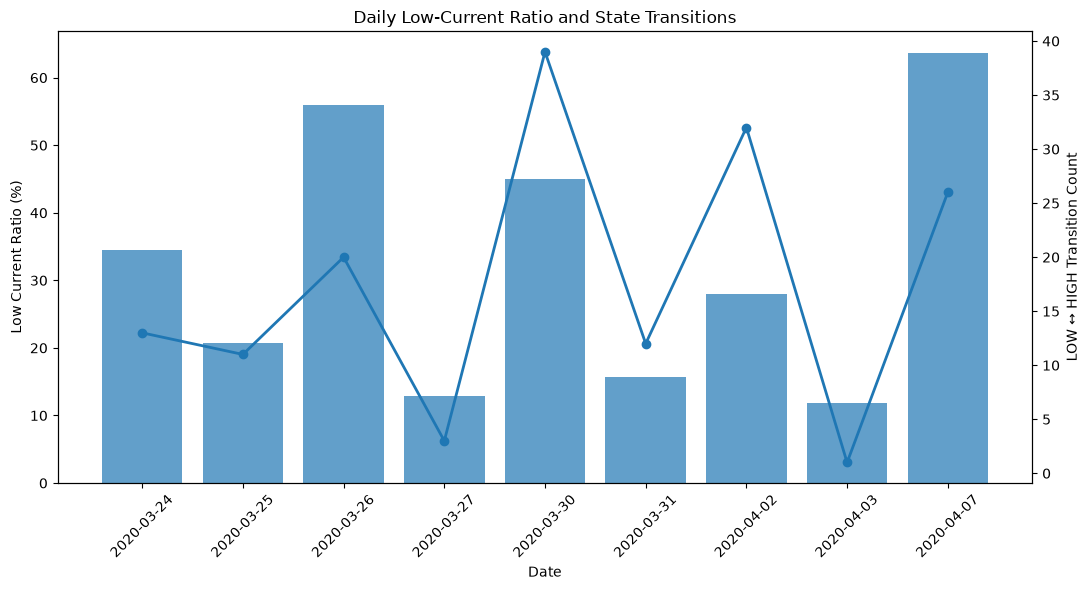

            Low_Current_Ratio  Transition_Count  Mean_Low_Run  Max_Low_Run
Date                                                                      
2020-03-24          34.500000                13     59.142857          398
2020-03-25          20.784024                11     46.833333          268
2020-03-26          56.000000                20     56.000000          268
2020-03-27          12.864078                 3    106.000000          210
2020-03-30          44.965986                39     33.050000          268
2020-03-31          15.666667                12     47.000000          268
2020-04-02          28.000000                32     35.000000          268
2020-04-03          11.875000                 1     95.000000           95
2020-04-07          63.677130                26     30.428571          173


In [46]:
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in result.index]

# 저전류 비율
ax1.bar(
    dates,
    result["Low_Current_Ratio"],
    alpha=0.7,
    label="Low Current Ratio"
)

ax1.set_ylabel("Low Current Ratio (%)")
ax1.set_xlabel("Date")

# 전환 횟수
ax2 = ax1.twinx()

ax2.plot(
    dates,
    result["Transition_Count"],
    marker="o",
    linewidth=2,
    label="Transition Count"
)

ax2.set_ylabel("LOW ↔ HIGH Transition Count")

plt.title("Daily Low-Current Ratio and State Transitions")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(result)

            N_Rows  Low_Current_Ratio  Transition_Count  Transition_Rate  \
Date                                                                       
2020-03-24    1200              34.50                13             1.08   
2020-03-25    1352              20.78                11             0.81   
2020-03-26    1000              56.00                20             2.00   
2020-03-27    1648              12.86                 3             0.18   
2020-03-30    1470              44.97                39             2.65   
2020-03-31    1800              15.67                12             0.67   
2020-04-02    2000              28.00                32             1.60   
2020-04-03     800              11.88                 1             0.13   
2020-04-07     669              63.68                26             3.89   

            Mean_Low_Run  Max_Low_Run  
Date                                   
2020-03-24         59.14          398  
2020-03-25         46.83          268  
202

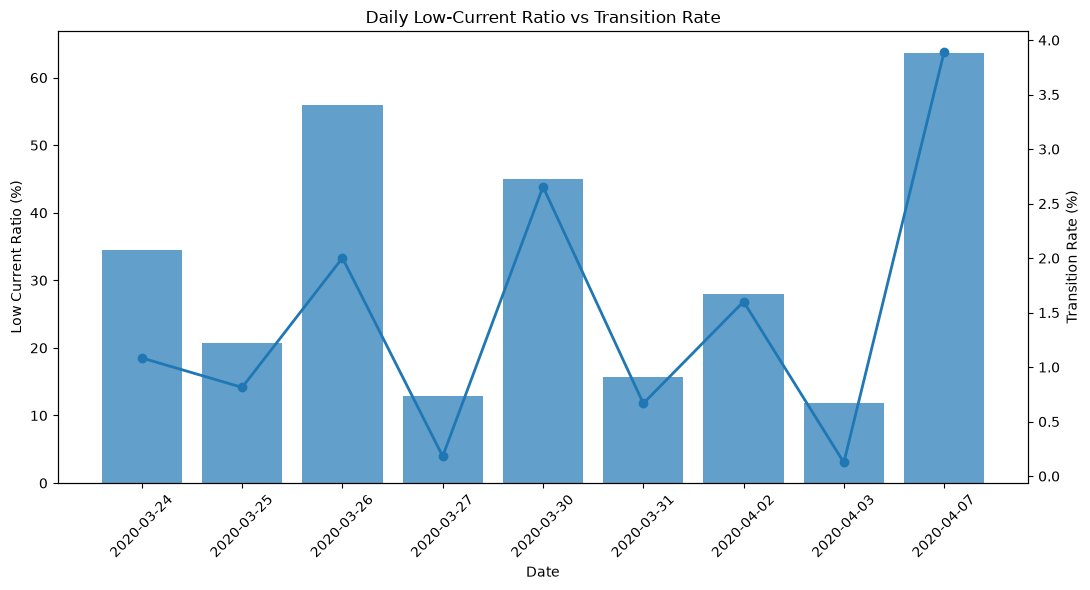

In [47]:
# 생산량 차이를 보정한 전환율(%)
daily_n = analysis_df.groupby("date").size()

result["N_Rows"] = daily_n

result["Transition_Rate"] = (
    result["Transition_Count"]
    / (result["N_Rows"] - 1)
    * 100
)

print(
    result[
        [
            "N_Rows",
            "Low_Current_Ratio",
            "Transition_Count",
            "Transition_Rate",
            "Mean_Low_Run",
            "Max_Low_Run"
        ]
    ].round(2)
)

# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = [str(x) for x in result.index]

ax1.bar(
    dates,
    result["Low_Current_Ratio"],
    alpha=0.7
)

ax1.set_ylabel("Low Current Ratio (%)")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    dates,
    result["Transition_Rate"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Transition Rate (%)")

plt.title("Daily Low-Current Ratio vs Transition Rate")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

=== Spearman Correlation ===
                   Current_MAD  Low_Current_Ratio  Transition_Rate  \
Current_MAD              1.000              0.228            0.127   
Low_Current_Ratio        0.228              1.000            0.967   
Transition_Rate          0.127              0.967            1.000   
Mean_Low_Run            -0.025             -0.667           -0.800   
Max_Low_Run             -0.139              0.292            0.237   

                   Mean_Low_Run  Max_Low_Run  
Current_MAD              -0.025       -0.139  
Low_Current_Ratio        -0.667        0.292  
Transition_Rate          -0.800        0.237  
Mean_Low_Run              1.000       -0.091  
Max_Low_Run              -0.091        1.000  


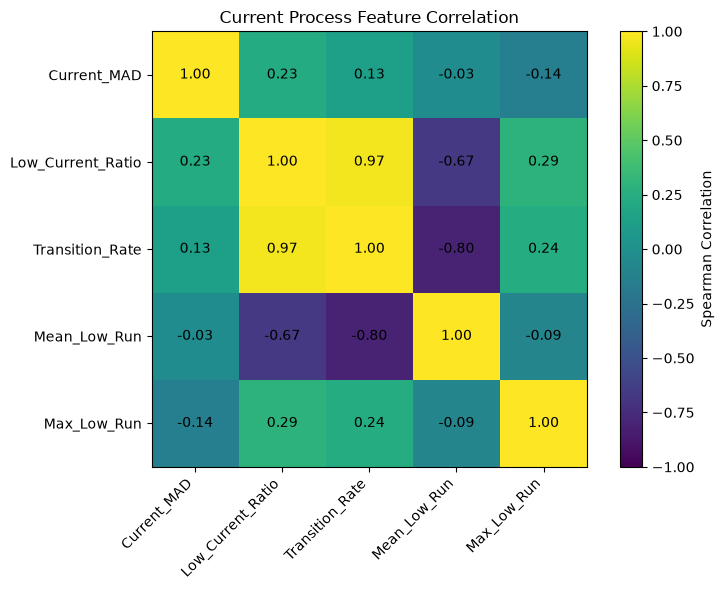

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Current MAD 추가
result["Current_MAD"] = daily_mad

# 비교할 변수
cols = [
    "Current_MAD",
    "Low_Current_Ratio",
    "Transition_Rate",
    "Mean_Low_Run",
    "Max_Low_Run"
]

# 상관계수
corr = result[cols].corr(method="spearman")

print("=== Spearman Correlation ===")
print(corr.round(3))


# 상관관계 시각화
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))

ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# 숫자 표시
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im, label="Spearman Correlation")
plt.title("Current Process Feature Correlation")

plt.tight_layout()
plt.show()

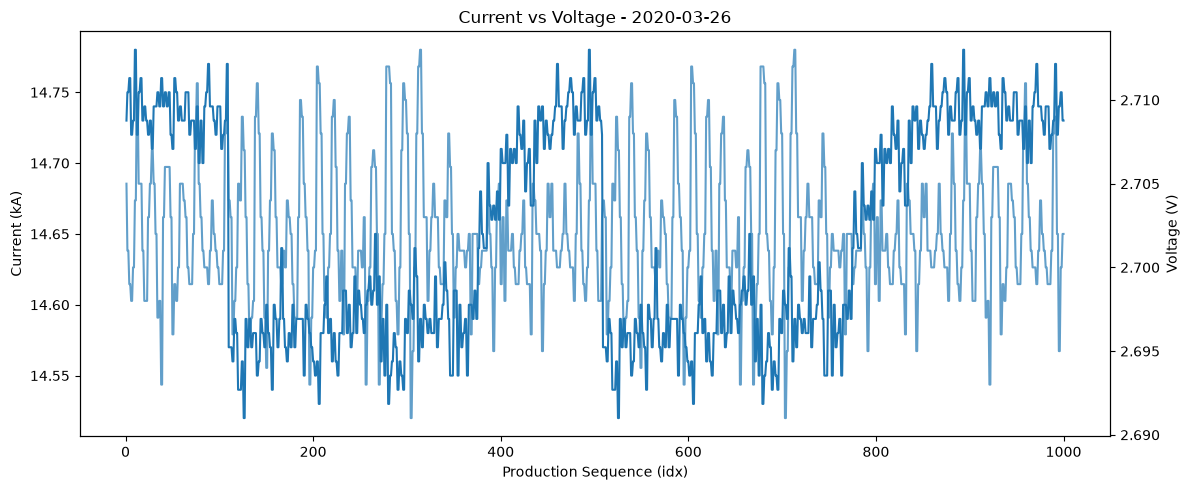

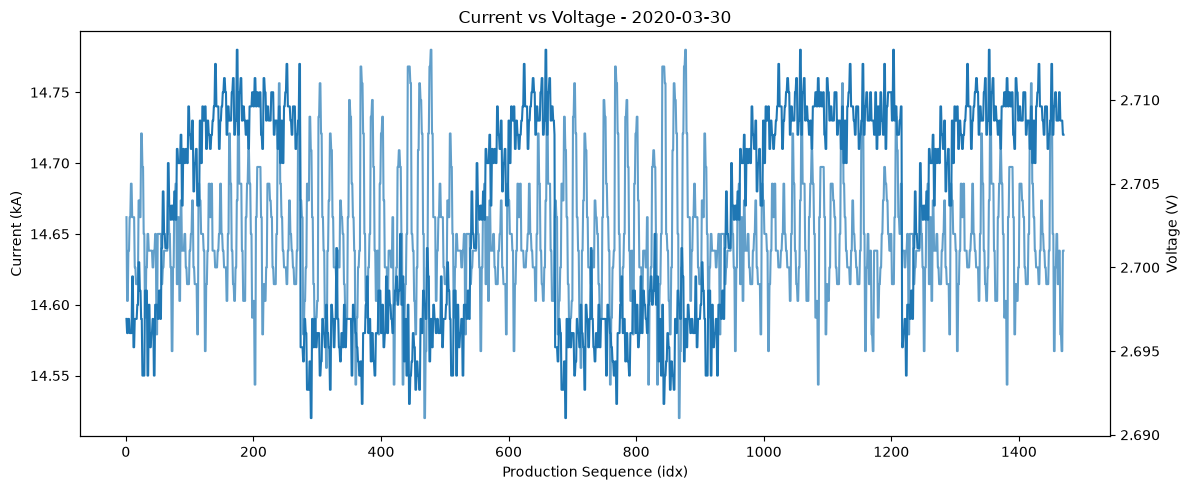

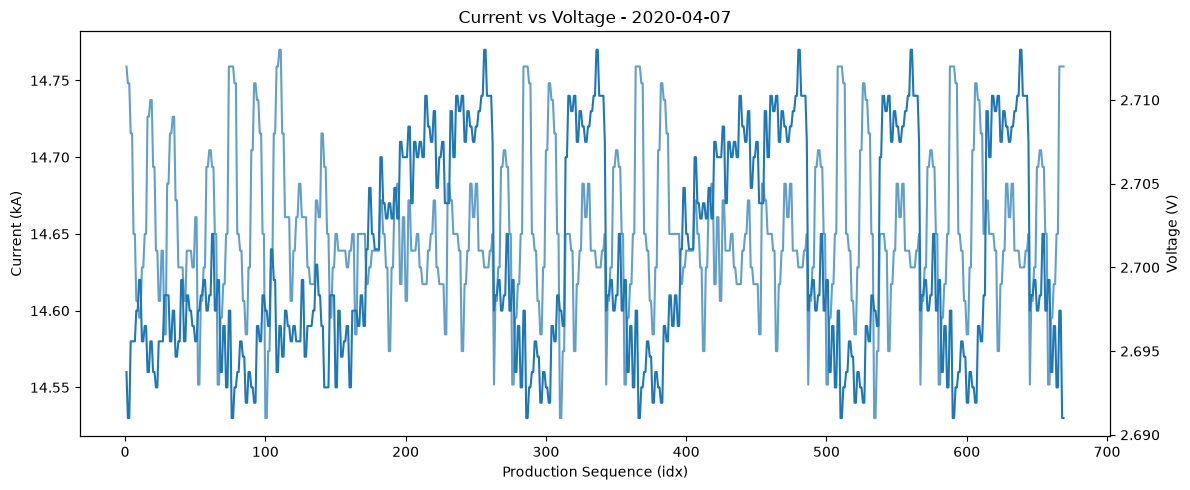

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 + 생산순서 정렬
plot_df = df.dropna(
    subset=["date", "idx", "weld current(kA)", "weld Voltage(v)"]
).copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values(["date", "idx"])

# 우선 확인할 날짜
dates = ["2020-03-26", "2020-03-30", "2020-04-07"]

for date in dates:

    temp = plot_df[
        plot_df["date"] == pd.to_datetime(date)
    ].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Current
    ax1.plot(
        temp["idx"],
        temp["weld current(kA)"],
        label="Current"
    )

    ax1.set_xlabel("Production Sequence (idx)")
    ax1.set_ylabel("Current (kA)")

    # Voltage용 두 번째 Y축
    ax2 = ax1.twinx()

    ax2.plot(
        temp["idx"],
        temp["weld Voltage(v)"],
        alpha=0.7,
        label="Voltage"
    )

    ax2.set_ylabel("Voltage (V)")

    plt.title(f"Current vs Voltage - {date}")
    plt.tight_layout()
    plt.show()

In [50]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []

for date, temp in plot_df.groupby("date"):

    temp = temp.dropna(
        subset=["weld current(kA)", "weld Voltage(v)"]
    )

    pearson_r, pearson_p = pearsonr(
        temp["weld current(kA)"],
        temp["weld Voltage(v)"]
    )

    spearman_r, spearman_p = spearmanr(
        temp["weld current(kA)"],
        temp["weld Voltage(v)"]
    )

    results.append({
        "Date": date,
        "Pearson": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman": spearman_r,
        "Spearman_p": spearman_p
    })

corr_result = pd.DataFrame(results)

print(corr_result.round(4))

        Date  Pearson  Pearson_p  Spearman  Spearman_p
0 2020-03-24  -0.0902     0.0018   -0.1114      0.0001
1 2020-03-25   0.1392     0.0000    0.1390      0.0000
2 2020-03-26  -0.1259     0.0001   -0.1256      0.0001
3 2020-03-27   0.1343     0.0000    0.0750      0.0023
4 2020-03-30  -0.1141     0.0000   -0.0932      0.0003
5 2020-03-31   0.1378     0.0000    0.0872      0.0002
6 2020-04-02  -0.0572     0.0105   -0.0685      0.0022
7 2020-04-03   0.1267     0.0003    0.1732      0.0000
8 2020-04-07  -0.2317     0.0000   -0.2011      0.0000


C:\Users\sj789\AppData\Local\Temp\ipykernel_2116\444862009.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(corr_result.round(4))


=== Daily Voltage Statistics ===
            Voltage_Median  Voltage_MAD
date                                   
2020-03-24           2.702        0.003
2020-03-25           2.702        0.004
2020-03-26           2.701        0.002
2020-03-27           2.703        0.004
2020-03-30           2.701        0.002
2020-03-31           2.702        0.004
2020-04-02           2.702        0.003
2020-04-03           2.703        0.006
2020-04-07           2.701        0.002


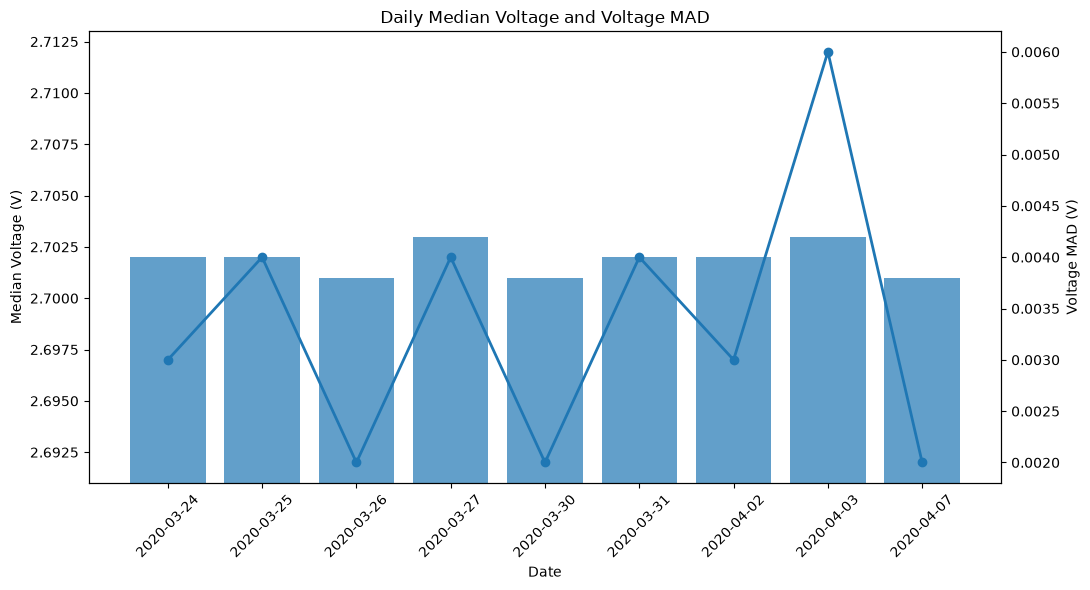

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 날짜 형식
df["date"] = pd.to_datetime(df["date"])

# MAD 함수
def mad(x):
    median = x.median()
    return np.median(np.abs(x - median))

# 날짜별 Voltage 중앙값 + MAD
voltage_daily = df.groupby("date")["weld Voltage(v)"].agg(
    Voltage_Median="median",
    Voltage_MAD=mad
)

print("=== Daily Voltage Statistics ===")
print(voltage_daily.round(4))


# 그래프
fig, ax1 = plt.subplots(figsize=(11, 6))

dates = voltage_daily.index.strftime("%Y-%m-%d")

# Voltage 중앙값
ax1.bar(
    dates,
    voltage_daily["Voltage_Median"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Voltage (V)")
ax1.set_ylim(
    voltage_daily["Voltage_Median"].min() - 0.01,
    voltage_daily["Voltage_Median"].max() + 0.01
)

# Voltage MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    voltage_daily["Voltage_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Voltage MAD (V)")

plt.title("Daily Median Voltage and Voltage MAD")
ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

            Current_MAD  Voltage_MAD
date                                
2020-03-24        0.040        0.003
2020-03-25        0.060        0.004
2020-03-26        0.060        0.002
2020-03-27        0.030        0.004
2020-03-30        0.050        0.002
2020-03-31        0.030        0.004
2020-04-02        0.020        0.003
2020-04-03        0.055        0.006
2020-04-07        0.050        0.002

=== Current MAD vs Voltage MAD ===
Pearson  : -0.043  (p=0.912)
Spearman : -0.156  (p=0.689)


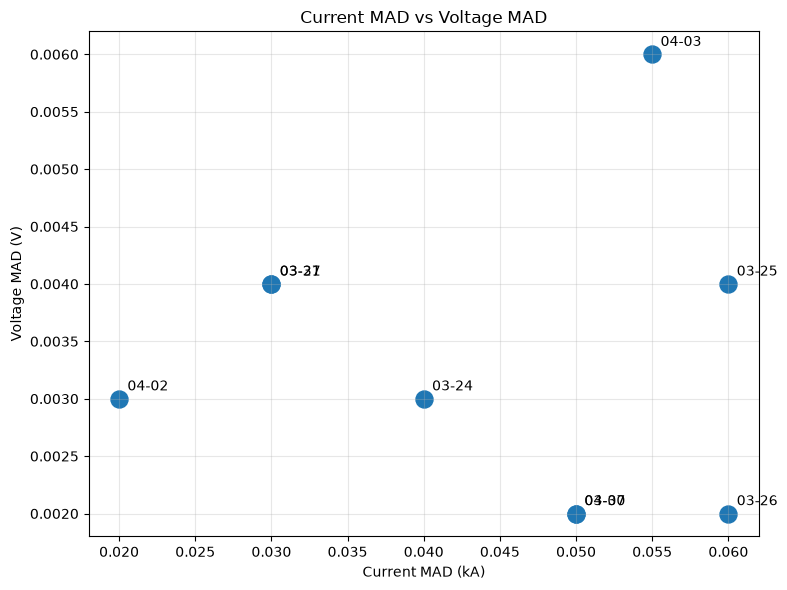

In [52]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# MAD 함수
def mad(x):
    med = x.median()
    return np.median(np.abs(x - med))

# 날짜별 Current MAD / Voltage MAD
mad_compare = df.groupby("date").agg(
    Current_MAD=("weld current(kA)", mad),
    Voltage_MAD=("weld Voltage(v)", mad)
)

# 상관계수
pearson_r, pearson_p = pearsonr(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"]
)

spearman_r, spearman_p = spearmanr(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"]
)

print(mad_compare.round(4))

print("\n=== Current MAD vs Voltage MAD ===")
print(f"Pearson  : {pearson_r:.3f}  (p={pearson_p:.3f})")
print(f"Spearman : {spearman_r:.3f}  (p={spearman_p:.3f})")


# 그래프
plt.figure(figsize=(8, 6))

plt.scatter(
    mad_compare["Current_MAD"],
    mad_compare["Voltage_MAD"],
    s=150
)

# 날짜 표시
for date, row in mad_compare.iterrows():

    plt.annotate(
        pd.to_datetime(date).strftime("%m-%d"),
        (
            row["Current_MAD"],
            row["Voltage_MAD"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Current MAD (kA)")
plt.ylabel("Voltage MAD (V)")
plt.title("Current MAD vs Voltage MAD")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Daily Resistance ===
            Resistance_Median  Resistance_MAD
date                                         
2020-03-24           0.183639        0.000605
2020-03-25           0.183537        0.000981
2020-03-26           0.184565        0.000927
2020-03-27           0.183379        0.000632
2020-03-30           0.183924        0.000749
2020-03-31           0.183435        0.000644
2020-04-02           0.183571        0.000509
2020-04-03           0.183311        0.001366
2020-04-07           0.184710        0.000867


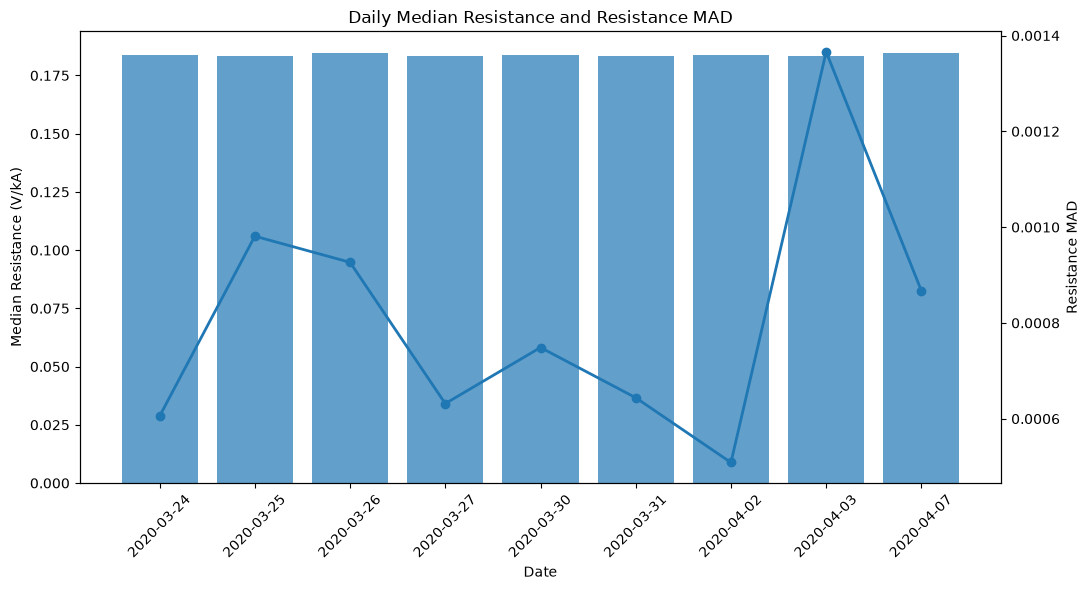

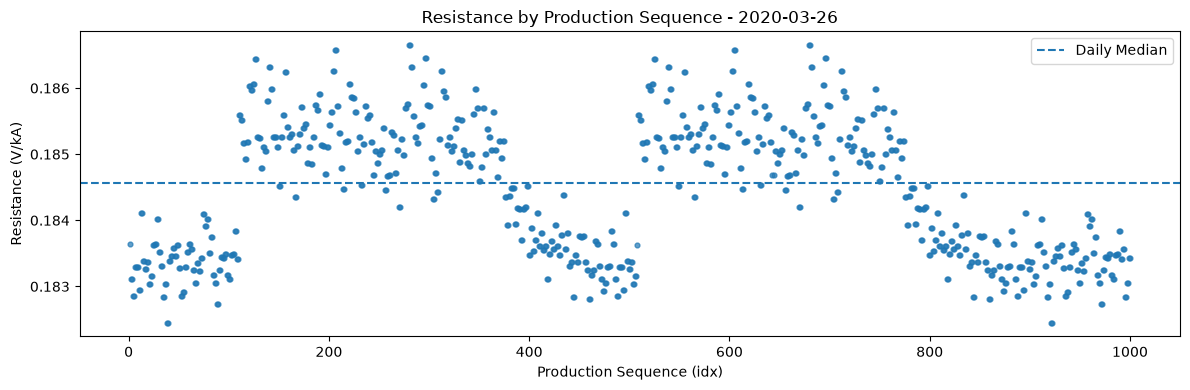

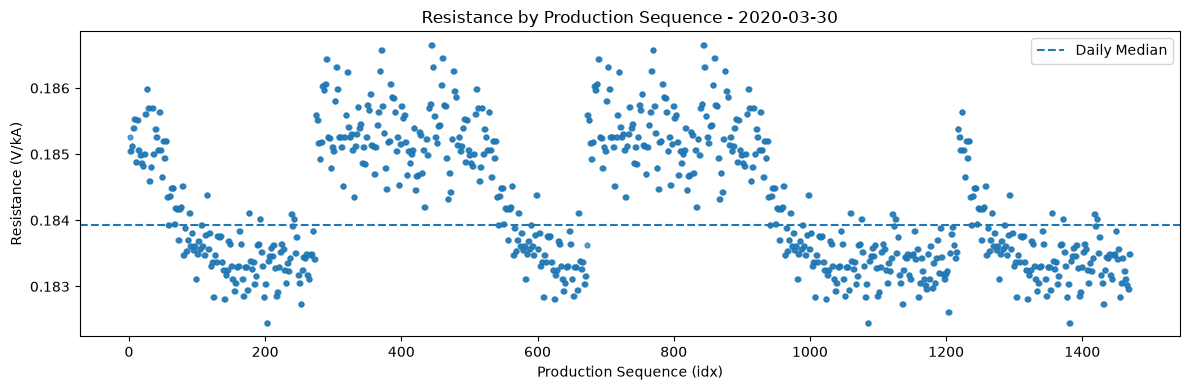

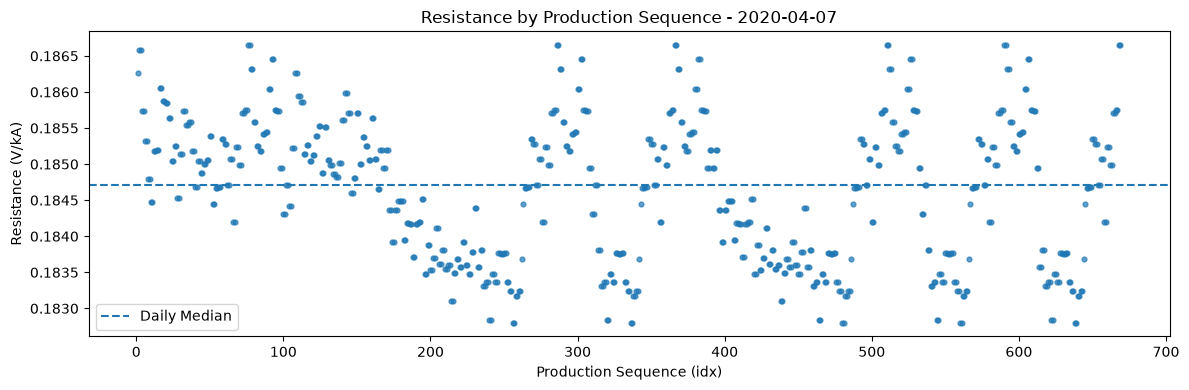

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Resistance 파생변수 생성
# R = V / I
# ==========================================

df["Resistance"] = (
    df["weld Voltage(v)"] /
    df["weld current(kA)"]
)


# ==========================================
# 2. MAD 함수
# ==========================================

def mad(x):
    median = x.median()
    return np.median(np.abs(x - median))


# ==========================================
# 3. 날짜별 Resistance 중앙값 + MAD
# ==========================================

resistance_daily = df.groupby("date")["Resistance"].agg(
    Resistance_Median="median",
    Resistance_MAD=mad
)

print("=== Daily Resistance ===")
print(resistance_daily.round(6))


# ==========================================
# 4. 날짜별 Resistance 중앙값 + MAD 그래프
# ==========================================

fig, ax1 = plt.subplots(figsize=(11, 6))

dates = pd.to_datetime(
    resistance_daily.index
).strftime("%Y-%m-%d")

# 중앙값
ax1.bar(
    dates,
    resistance_daily["Resistance_Median"],
    alpha=0.7
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Median Resistance (V/kA)")

# MAD
ax2 = ax1.twinx()

ax2.plot(
    dates,
    resistance_daily["Resistance_MAD"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Resistance MAD")

plt.title("Daily Median Resistance and Resistance MAD")

ax1.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ==========================================
# 5. 생산순서별 Resistance
# ==========================================

target_dates = [
    "2020-03-26",
    "2020-03-30",
    "2020-04-07"
]

df["date"] = pd.to_datetime(df["date"])

for date in target_dates:

    temp = df[
        df["date"] == pd.to_datetime(date)
    ].sort_values("idx")

    plt.figure(figsize=(12, 4))

    plt.scatter(
        temp["idx"],
        temp["Resistance"],
        s=12,
        alpha=0.7
    )

    plt.axhline(
        temp["Resistance"].median(),
        linestyle="--",
        label="Daily Median"
    )

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Resistance (V/kA)")
    plt.title(f"Resistance by Production Sequence - {date}")

    plt.legend()
    plt.tight_layout()
    plt.show()

=== Current vs Resistance ===
Pearson  : -0.5241 (p=0)
Spearman : -0.7239 (p=0)


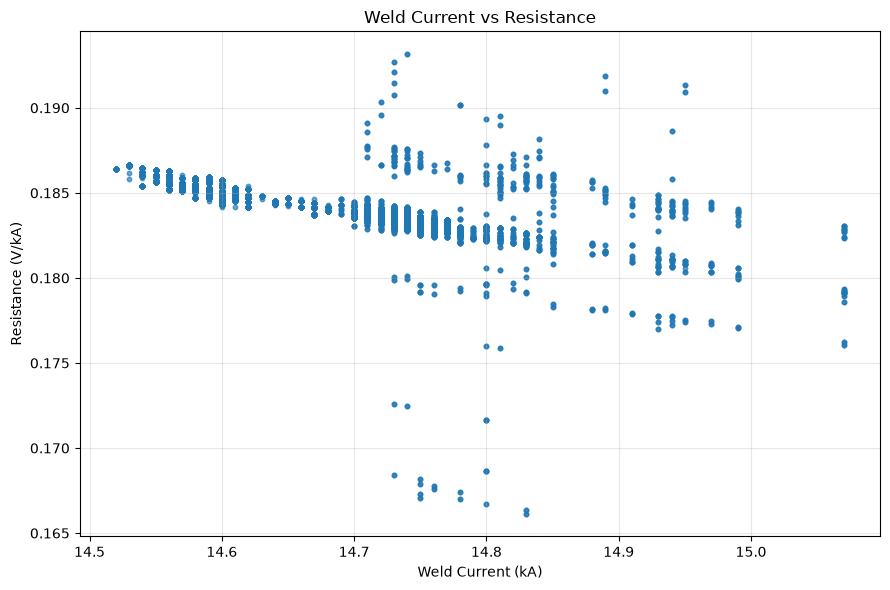

In [54]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import matplotlib.pyplot as plt

# Current와 Resistance 결측치 제거
temp = df[
    ["weld current(kA)", "Resistance"]
].dropna()

# 전체 행 기준 상관관계
pearson_r, pearson_p = pearsonr(
    temp["weld current(kA)"],
    temp["Resistance"]
)

spearman_r, spearman_p = spearmanr(
    temp["weld current(kA)"],
    temp["Resistance"]
)

print("=== Current vs Resistance ===")
print(f"Pearson  : {pearson_r:.4f} (p={pearson_p:.4g})")
print(f"Spearman : {spearman_r:.4f} (p={spearman_p:.4g})")


# 산점도
plt.figure(figsize=(9, 6))

plt.scatter(
    temp["weld current(kA)"],
    temp["Resistance"],
    s=10,
    alpha=0.4
)

plt.xlabel("Weld Current (kA)")
plt.ylabel("Resistance (V/kA)")
plt.title("Weld Current vs Resistance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

사용 행 개수: 11939
K=2 / Silhouette=0.7070
K=3 / Silhouette=0.7335
K=4 / Silhouette=0.6577
K=5 / Silhouette=0.6633
K=6 / Silhouette=0.6721


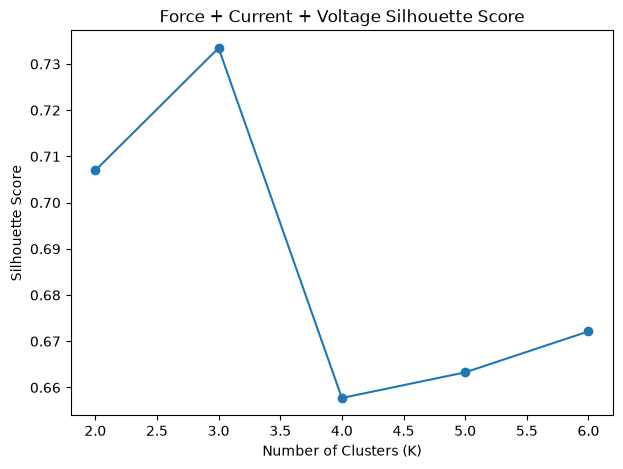


Best K = 3


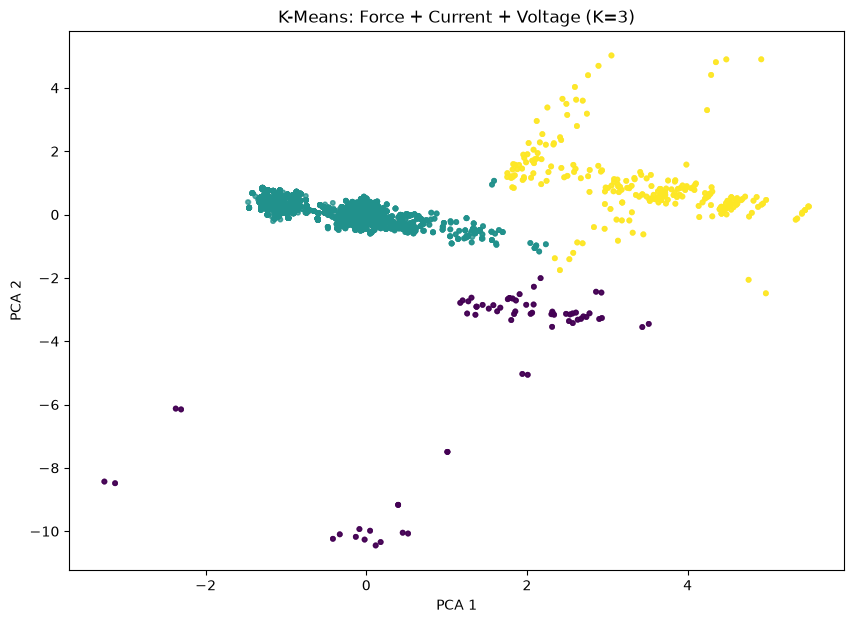


=== Cluster Count ===
Cluster
0      280
1    10743
2      916
Name: count, dtype: int64

=== Cluster Mean ===
         weld force(bar)  weld current(kA)  weld Voltage(v)
Cluster                                                    
0                 7.1956           14.8349           2.6104
1                 2.3380           14.6966           2.7022
2                 6.7173           14.8453           2.7565

=== Cluster Median ===
         weld force(bar)  weld current(kA)  weld Voltage(v)
Cluster                                                    
0                  6.875             14.80            2.651
1                  2.330             14.73            2.702
2                  7.890             14.83            2.754


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# ==========================================
# 1. 사용할 변수
# ==========================================

features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)"
]

data = df[features].dropna().copy()

print("사용 행 개수:", len(data))


# ==========================================
# 2. 표준화
# ==========================================

scaler = StandardScaler()
X = scaler.fit_transform(data)


# ==========================================
# 3. K = 2~6 비교
# ==========================================

scores = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)
    scores.append(score)

    print(f"K={k} / Silhouette={score:.4f}")


# 그래프
plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 7),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Force + Current + Voltage Silhouette Score")

plt.show()


# ==========================================
# 4. 가장 좋은 K 자동 선택
# ==========================================

best_k = range(2, 7)[scores.index(max(scores))]

print("\nBest K =", best_k)


# ==========================================
# 5. 최종 K-Means
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X)


# ==========================================
# 6. PCA 2차원 시각화
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=data["Cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    f"K-Means: Force + Current + Voltage (K={best_k})"
)

plt.show()


# ==========================================
# 7. 클러스터 결과
# ==========================================

print("\n=== Cluster Count ===")
print(data["Cluster"].value_counts().sort_index())

print("\n=== Cluster Mean ===")
print(
    data.groupby("Cluster")[features]
    .mean()
    .round(4)
)

print("\n=== Cluster Median ===")
print(
    data.groupby("Cluster")[features]
    .median()
    .round(4)
)

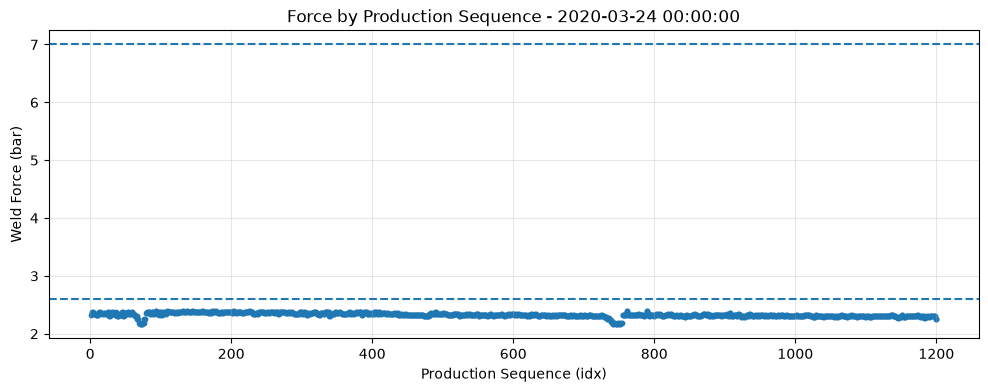

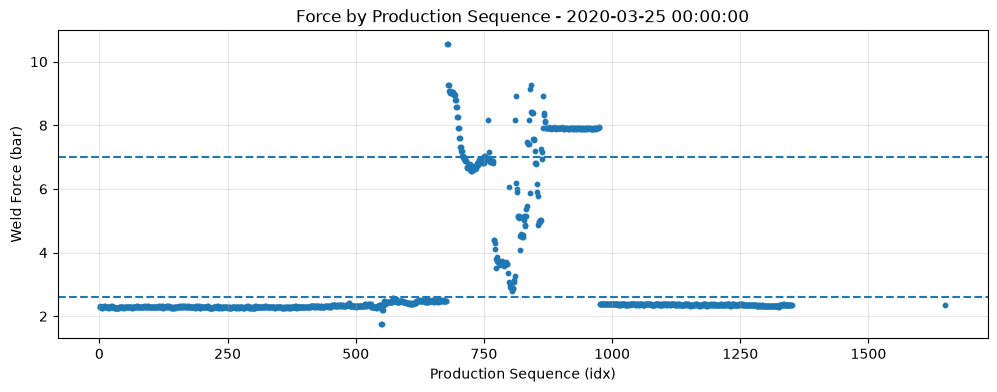

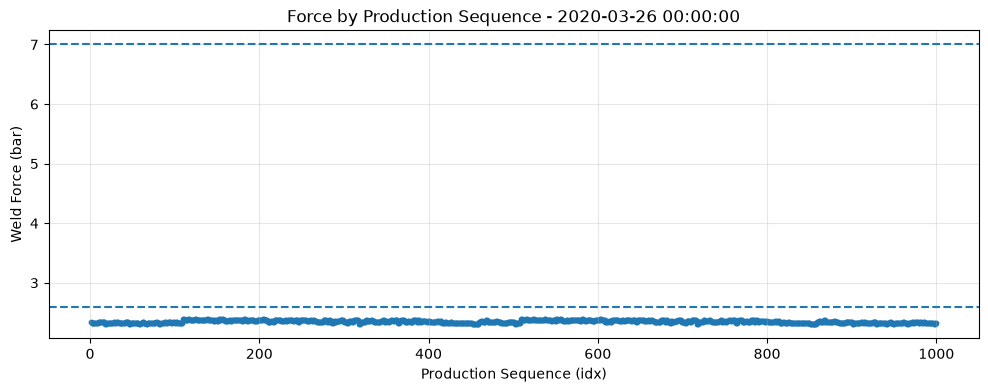

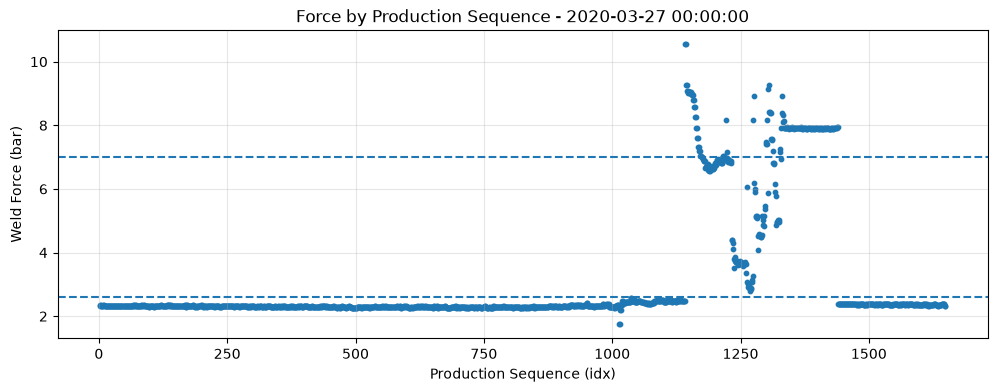

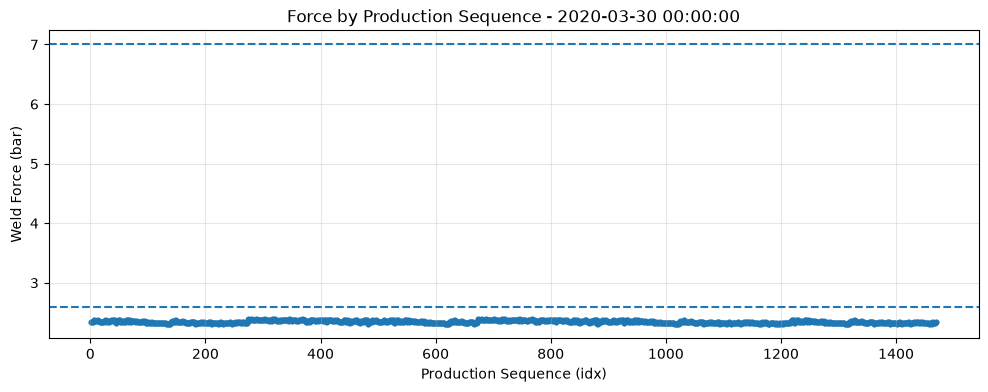

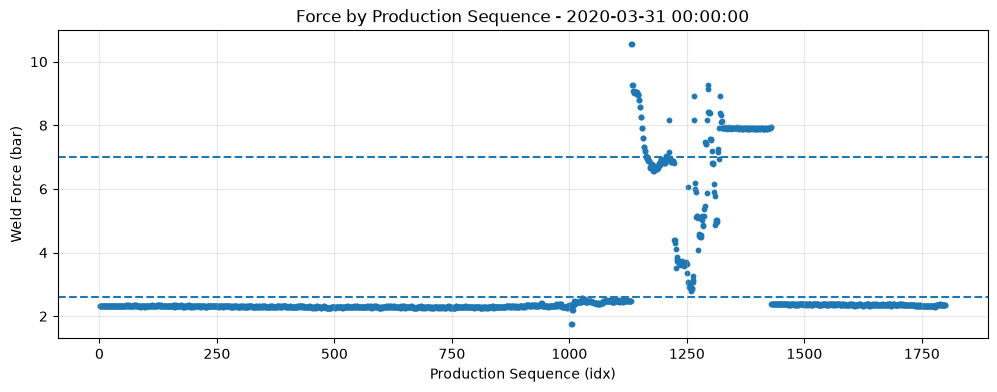

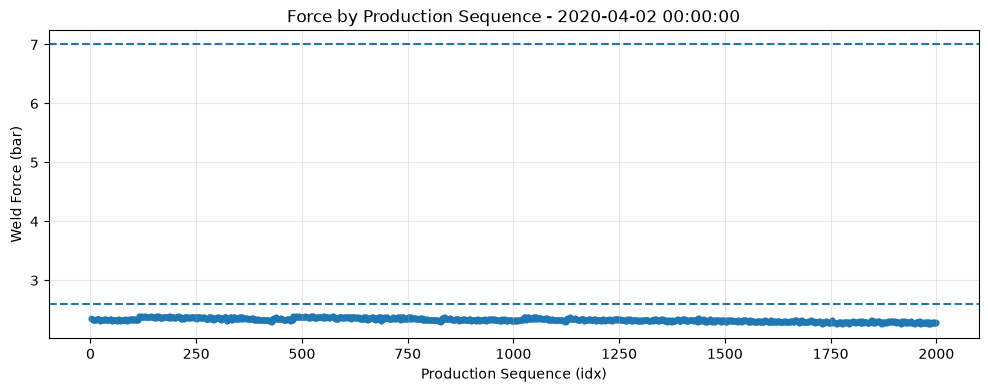

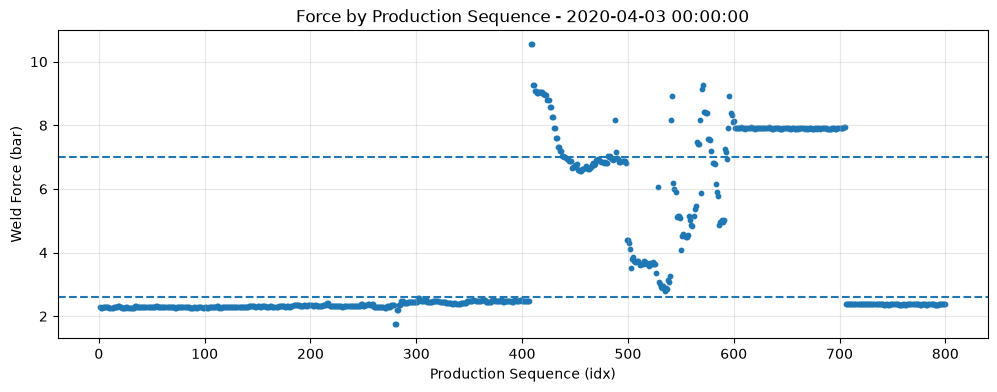

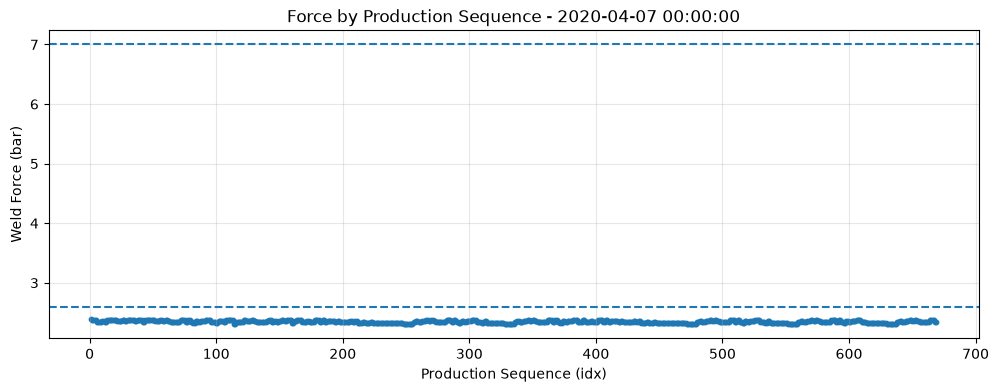

In [ ]:

# Force 7~8 bar 데이터가 무작위로 발생한 이상치가 아니라, 특정 날짜·생산구간에 연속적으로 나타나는 별도의 공정조건일 것이다.

import matplotlib.pyplot as plt

dates = sorted(df["date"].unique())

for date in dates:
    temp = df[df["date"] == date].sort_values("idx")

    plt.figure(figsize=(12, 4))

    plt.scatter(
        temp["idx"],
        temp["weld force(bar)"],
        s=10
    )

    plt.axhline(2.6, linestyle="--")
    plt.axhline(7.0, linestyle="--")

    plt.xlabel("Production Sequence (idx)")
    plt.ylabel("Weld Force (bar)")
    plt.title(f"Force by Production Sequence - {date}")

    plt.grid(alpha=0.3)
    plt.show()

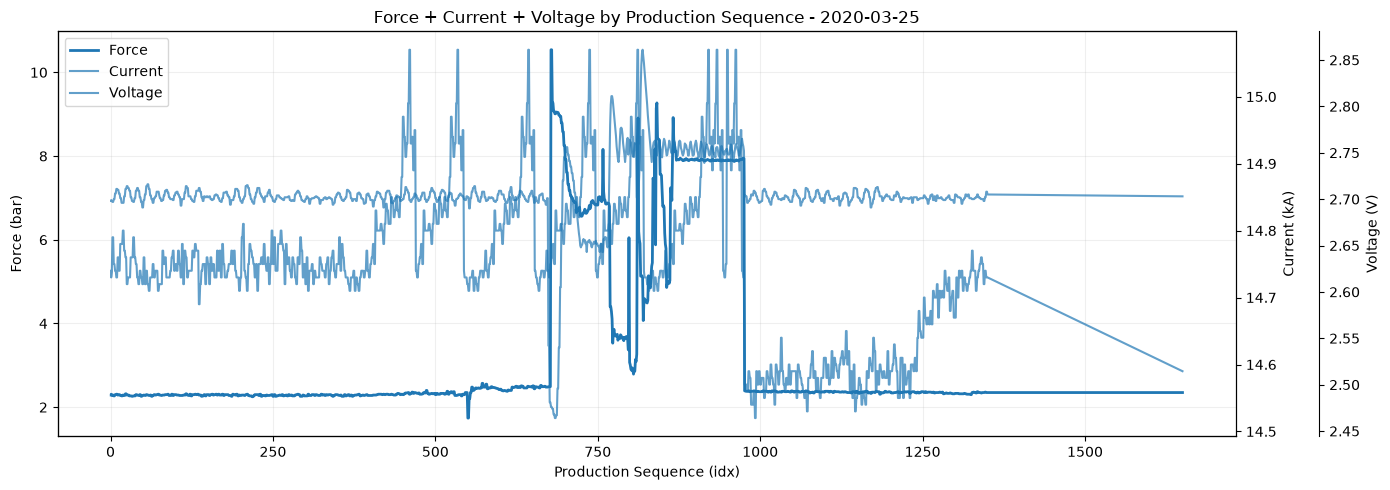

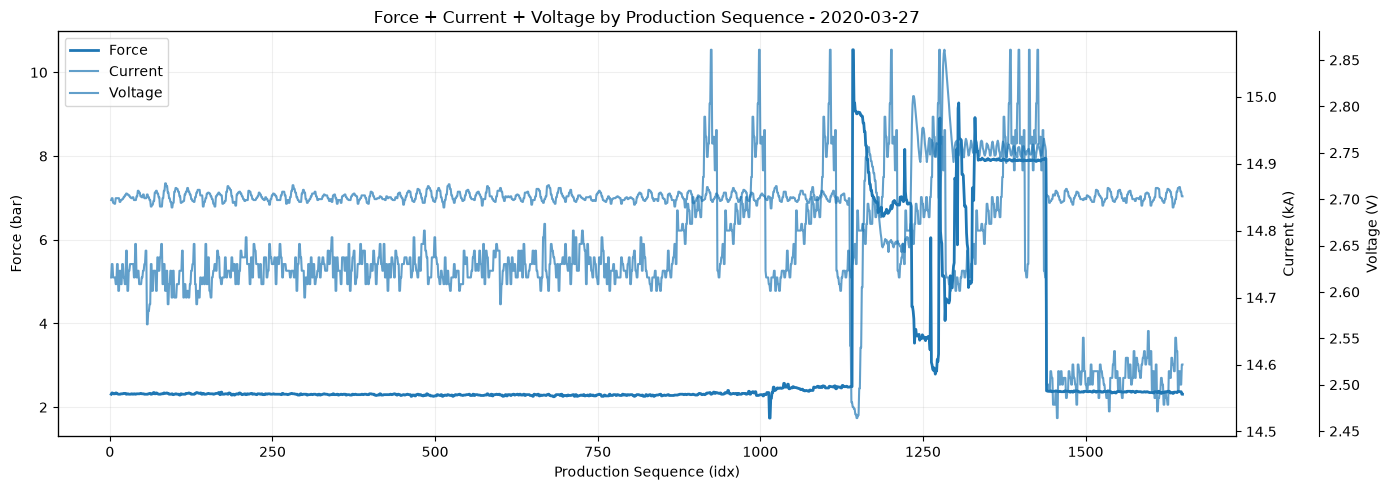

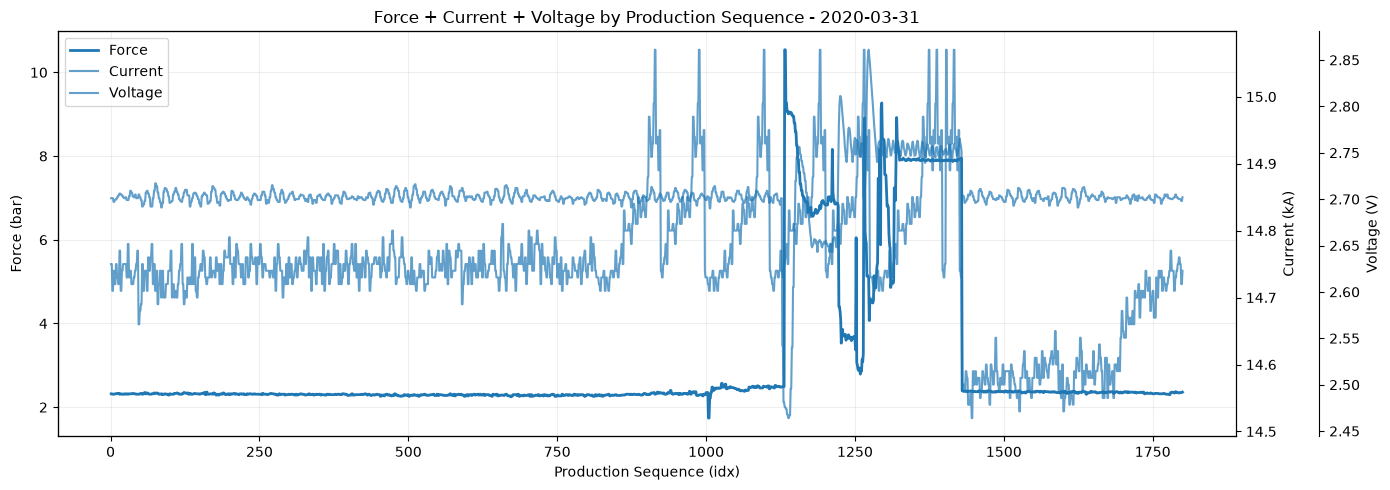

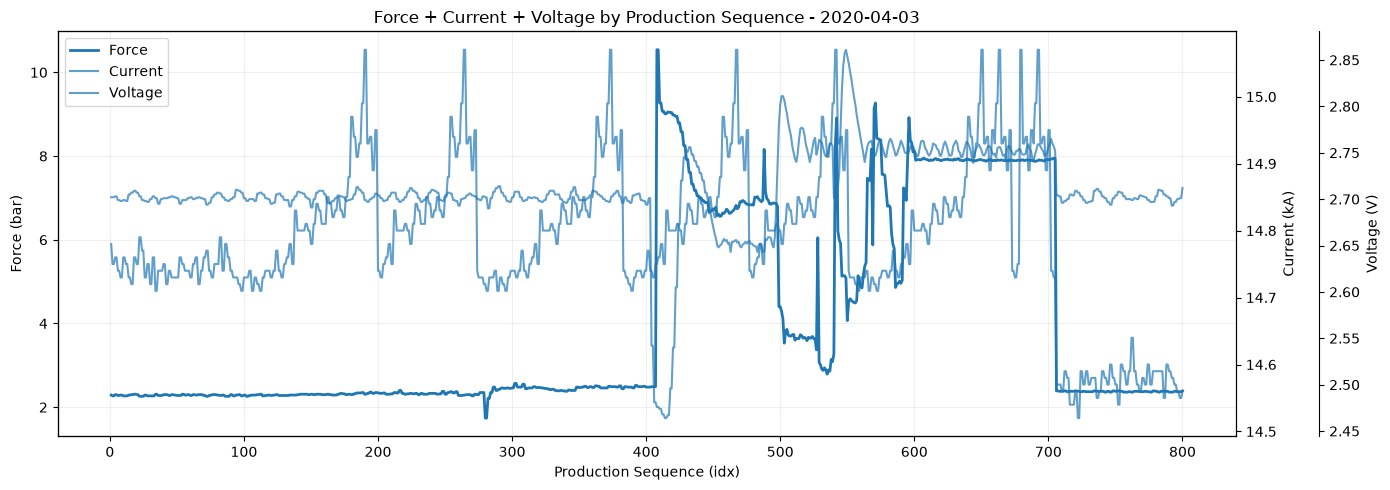

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

target_dates = [
    "2020-03-25",
    "2020-03-27",
    "2020-03-31",
    "2020-04-03"
]

for date in target_dates:

    temp = df[
        df["date"] == pd.to_datetime(date)
    ].sort_values("idx")

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # =========================
    # Force
    # =========================
    ax1.plot(
        temp["idx"],
        temp["weld force(bar)"],
        label="Force",
        linewidth=2
    )

    ax1.set_xlabel("Production Sequence (idx)")
    ax1.set_ylabel("Force (bar)")

    # =========================
    # Current
    # =========================
    ax2 = ax1.twinx()

    ax2.plot(
        temp["idx"],
        temp["weld current(kA)"],
        label="Current",
        alpha=0.7
    )

    ax2.set_ylabel("Current (kA)")

    # =========================
    # Voltage
    # =========================
    ax3 = ax1.twinx()

    # 세 번째 y축을 오른쪽으로 이동
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        temp["idx"],
        temp["weld Voltage(v)"],
        label="Voltage",
        alpha=0.7
    )

    ax3.set_ylabel("Voltage (V)")

    # =========================
    # 제목
    # =========================
    plt.title(
        f"Force + Current + Voltage by Production Sequence - {date}"
    )

    # 범례
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2 + lines3,
        labels1 + labels2 + labels3,
        loc="upper left"
    )

    ax1.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()